In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

survival_df = pd.read_csv("TCGA_data/survival_data.txt", sep="\t")
phenotype_df = pd.read_csv("TCGA_data/survival_full_set.csv")

merged_df = survival_df.merge(
    phenotype_df,
    on="sample",
    how="inner"
)

# Split by survival status
survived = merged_df[merged_df['OS'] == 1]
not_survived = merged_df[merged_df['OS'] == 0]

RT_df = merged_df[merged_df['treatment_or_therapy.treatments.diagnoses'] == "RT"]
TMZ_df = merged_df[merged_df["treatment_or_therapy.treatments.diagnoses"] == "TMZ"]
RT_and_TMZ_df = merged_df[merged_df["treatment_or_therapy.treatments.diagnoses"] == "RT/TMZ"]
no_treatment_df = merged_df[merged_df["treatment_or_therapy.treatments.diagnoses"] == "no treatment"]

# --- Event encoding ---
merged_df["event"] = merged_df["vital_status.demographic"].map({
    "Dead": 1,
    "Alive": 0
})

# --- Clean OS.time ---
merged_df["OS.time"] = pd.to_numeric(merged_df["OS.time"], errors="coerce")

# --- Drop missing required fields ---
merged_df = merged_df.dropna(subset=["OS.time", "event", "Methylation_Status"])

# --- TMZ group classification ---
def classify_tmz(val):
    val_str = str(val).lower()
    if "tmz" in val_str or "temozolomide" in val_str:
        return "TMZ"        # catches both "TMZ" and "RT/TMZ"
    else:
        return "Non-TMZ"    # catches RT alone, no treatment, etc.

merged_df["TMZ_group"] = merged_df[
    "treatment_or_therapy.treatments.diagnoses"
].apply(classify_tmz)

FileNotFoundError: [Errno 2] No such file or directory: 'TCGA_data/survival_data.txt'

In [2]:
#Cox Regression: Base Clinical Model 

# ── Cox Proportional Hazards: Base Clinical Model ───────────────────────────
from lifelines import CoxPHFitter
import pandas as pd

# --- Encode TMZ as binary ---
merged_df["TMZ_binary"] = (merged_df["TMZ_group"] == "TMZ").astype(int)

# --- Prepare Cox dataframe (only what we need) ---
cox_base_df = merged_df[["OS.time", "event", "TMZ_binary"]].dropna()

print("Cox base dataset shape:", cox_base_df.shape)
print("\nTMZ binary counts:")
print(cox_base_df["TMZ_binary"].value_counts())

Cox base dataset shape: (125, 3)

TMZ binary counts:
TMZ_binary
1    95
0    30
Name: count, dtype: int64


<lifelines.CoxPHFitter: fitted with 125 total observations, 36 right-censored observations>
             duration col = 'OS.time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 125
number of events observed = 89
   partial log-likelihood = -338.61
         time fit was run = 2026-02-28 12:06:55 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
TMZ_binary -0.81      0.45      0.24           -1.27           -0.35                0.28                0.71

            cmp to     z      p  -log2(p)
covariate                                
TMZ_binary    0.00 -3.43 <0.005     10.67
---
Concordance = 0.62
Partial AIC = 679.23
log-likelihood ratio test = 10.39 on 1 df
-log2(p) of ll-ratio test = 9.63

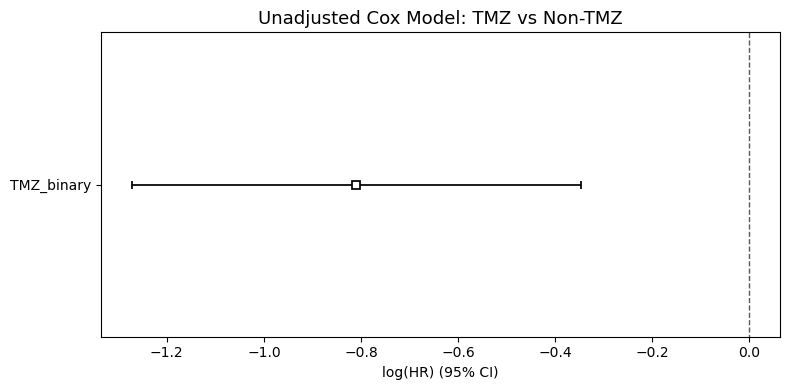

In [3]:
# ── Unadjusted Cox: TMZ Only ────────────────────────────────────────────────
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

cph = CoxPHFitter()
cph.fit(
    cox_base_df,
    duration_col="OS.time",
    event_col="event"
)

cph.print_summary()

# --- Forest plot ---
plt.figure(figsize=(8, 4))
cph.plot()
plt.title("Unadjusted Cox Model: TMZ vs Non-TMZ", fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# ── Adjusted Cox Setup ──────────────────────────────────────────────────────

merged_df["Age_years"] = merged_df["age_at_diagnosis.diagnoses"] / 365.25

# --- Preview key covariates ---
print("Age at diagnosis:")
print(merged_df["Age_years"].describe())

print("\nGender:")
print(merged_df["gender.demographic"].value_counts())

print("\nRace:")
print(merged_df["race.demographic"].value_counts())

print("\nMethylation Status:")
print(merged_df["Methylation_Status"].value_counts())

# --- Encode categorical variables ---
merged_df["Gender_binary"] = merged_df["gender.demographic"].map({
    "male":   0,
    "female": 1
})

# --- Encode race (dummy encode, drop most common as reference) ---
merged_df["Race_encoded"] = merged_df["race.demographic"].map({
    "white":                          0,
    "black or african american":      1,
    "asian":                          2,
    "american indian or alaska native": 3,
    "not reported":                   np.nan
})


# --- Prepare Cox dataframe ---
cox_adj_df = merged_df[[
    "OS.time",
    "event",
    "TMZ_binary",
    "Methylation_Status",
    "Age_years",
    "Gender_binary",
    "Race_encoded"
]].copy()

# --- Rename for readability ---
cox_adj_df = cox_adj_df.rename(columns={
    "Age_years": "Age",
    "Methylation_Status":         "MGMT_Methylation",
    "Gender_binary":              "Gender",
    "Race_encoded":               "Race"
})

# --- Convert to numeric ---
cox_adj_df["Age"] = pd.to_numeric(cox_adj_df["Age"], errors="coerce")

# --- Drop missing ---
cox_adj_df = cox_adj_df.dropna()

print("\nAdjusted Cox dataset shape:", cox_adj_df.shape)
print("\nColumn summary:")
print(cox_adj_df.describe())

Age at diagnosis:
count    125.000000
mean      60.732539
std       12.262823
min       21.429158
25%       52.673511
50%       60.815880
75%       70.162902
max       85.604381
Name: Age_years, dtype: float64

Gender:
gender.demographic
male      70
female    55
Name: count, dtype: int64

Race:
race.demographic
white                        98
black or african american    19
Name: count, dtype: int64

Methylation Status:
Methylation_Status
1.0    116
0.0      9
Name: count, dtype: int64

Adjusted Cox dataset shape: (117, 7)

Column summary:
           OS.time       event  TMZ_binary  MGMT_Methylation         Age  \
count   117.000000  117.000000  117.000000        117.000000  117.000000   
mean    401.606838    0.735043    0.743590          0.923077   60.417370   
std     451.179927    0.443209    0.438529          0.267615   12.355157   
min      24.000000    0.000000    0.000000          0.000000   21.429158   
25%     141.000000    0.000000    0.000000          1.000000   52.668036 

<lifelines.CoxPHFitter: fitted with 117 total observations, 31 right-censored observations>
             duration col = 'OS.time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 117
number of events observed = 86
   partial log-likelihood = -308.56
         time fit was run = 2026-02-28 12:06:55 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
TMZ_binary       -0.48      0.62      0.27           -1.01            0.05                0.36                1.06
MGMT_Methylation  0.03      1.03      0.52           -1.00            1.05                0.37                2.86
Age               0.05      1.06      0.01            0.03            0.08                1.03                1.08
Gender           -0.59      0.56      0.25           -1.07           -0.10                0.34                0.91
Race              0.18      1.20      0.32           -0.44            0.81                0.64                2.25

                  cmp to     z      p  -log2(p)
covariate                                      
TMZ_binary          0.00 -1.76   0.08      3.67
MGMT_Methylation    0.00  0.05   0.96      0.06
Age                 0.00  4.39 <0.005     16.40
Gender              0.00 -2.36   0.02      5.77
Race                0.00  0.58   0.56      0.83
---
Concordance = 0.70
Partial AIC = 627.13
log-likelihood ratio test = 36.17 on 5 df
-log2(p) of ll-ratio test = 20.12

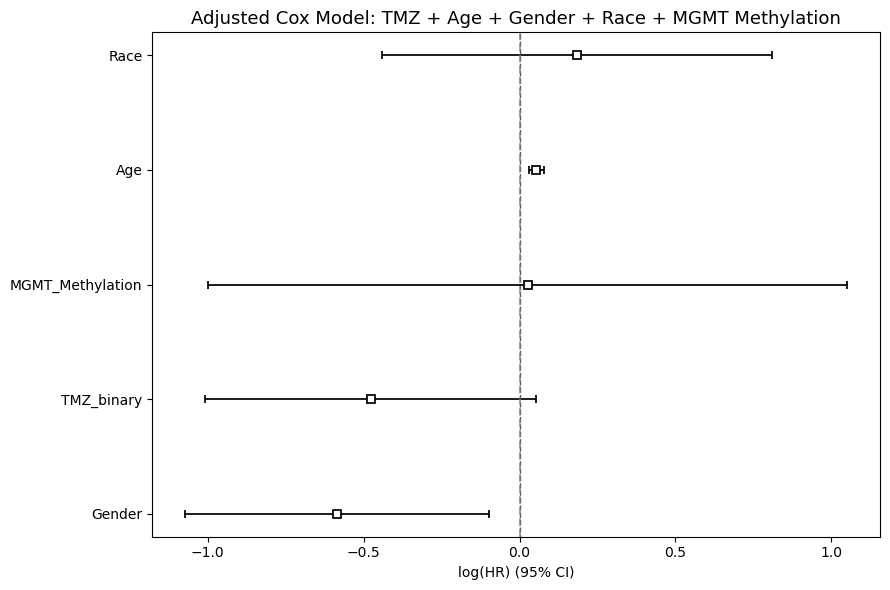

In [5]:
# --- Check all available columns ---
# ── Adjusted Cox: TMZ + Age + Gender + Race + MGMT Methylation ──────────────
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt

cph_adj = CoxPHFitter()
cph_adj.fit(
    cox_adj_df,
    duration_col="OS.time",
    event_col="event"
)

cph_adj.print_summary()

# --- Forest plot ---
plt.figure(figsize=(9, 6))
cph_adj.plot()
plt.title("Adjusted Cox Model: TMZ + Age + Gender + Race + MGMT Methylation", fontsize=13)
plt.axvline(x=0, linestyle="--", color="gray", alpha=0.7)
plt.tight_layout()
plt.show()

In [6]:
# Check the adjusted Cox model is fitted
print("Model covariates:", cph_adj.params_.index.tolist())
print("Number of observations:", cox_adj_df.shape[0])

Model covariates: ['TMZ_binary', 'MGMT_Methylation', 'Age', 'Gender', 'Race']
Number of observations: 117



   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'TMZ_binary' failed the non-proportional test: p-value is 0.0010.

   Advice: with so few unique values (only 2), you can include `strata=['TMZ_binary', ...]` in the
call in `.fit`. See documentation in link [E] below.

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readth

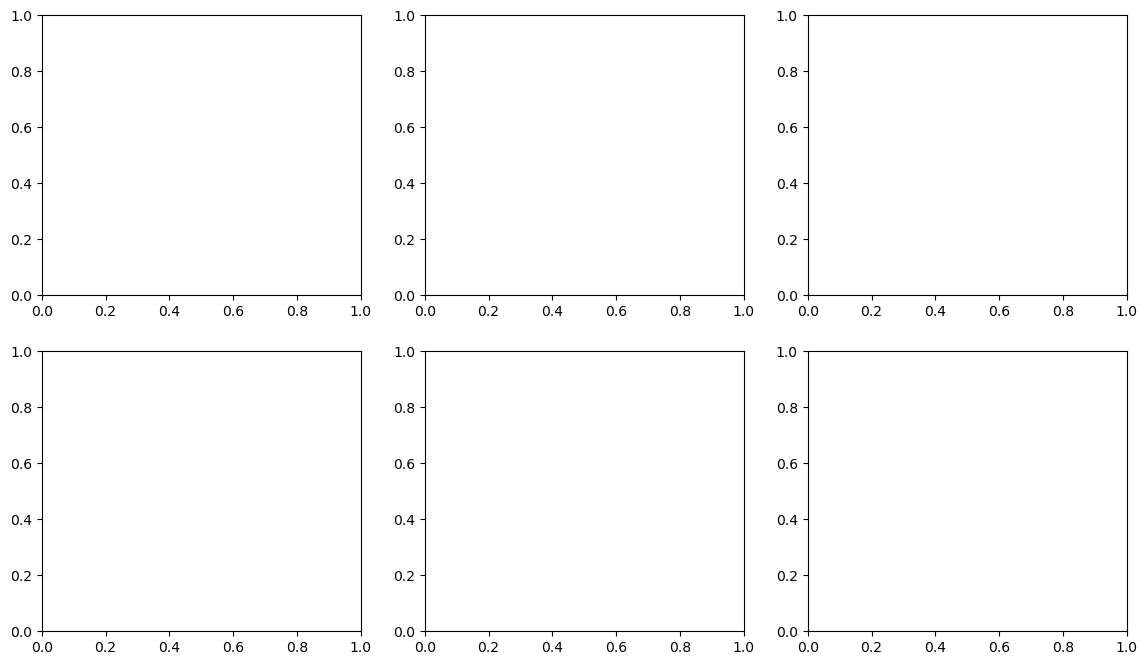

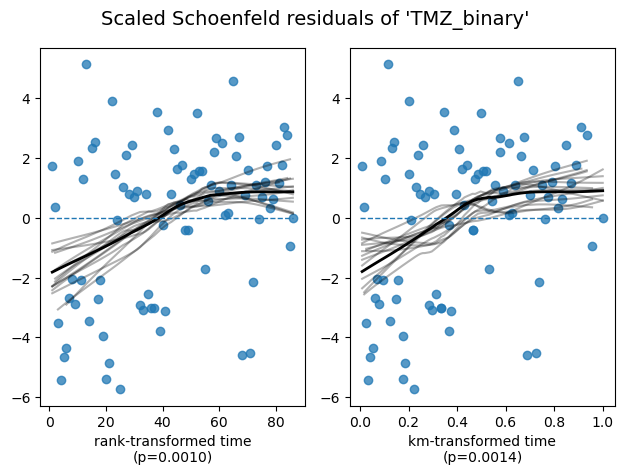

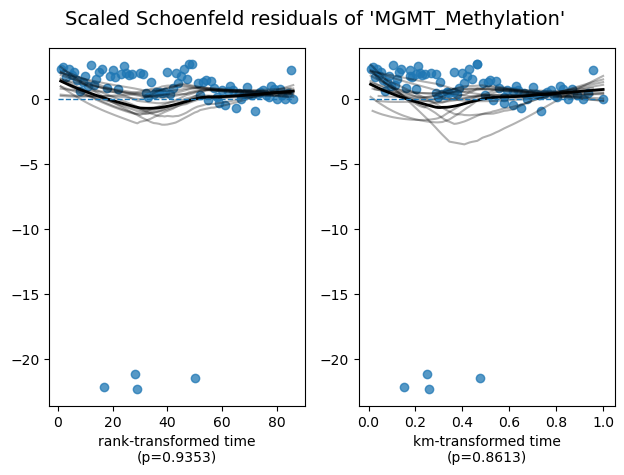

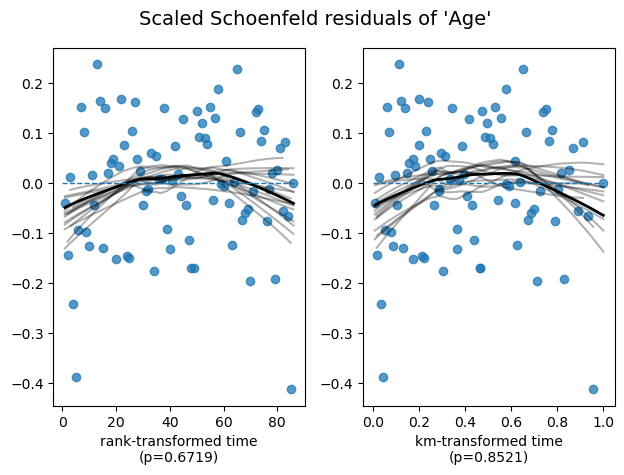

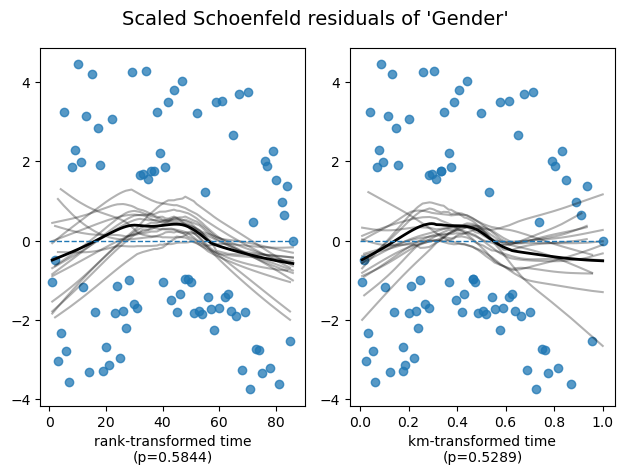

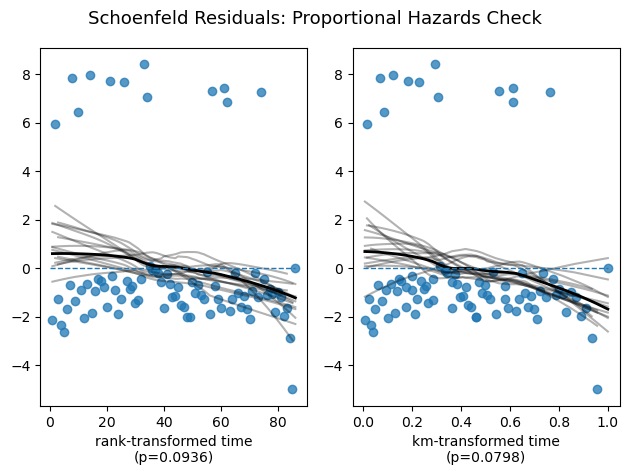

In [7]:
# ── Proportional Hazards Test: Schoenfeld Residuals ─────────────────────────
from lifelines.statistics import proportional_hazard_test
import matplotlib.pyplot as plt

# --- Run the test ---
results = proportional_hazard_test(cph_adj, cox_adj_df, time_transform="rank")
results.print_summary()

# --- Plot Schoenfeld residuals for each covariate ---
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

covariates = ["TMZ_binary", "MGMT_Methylation", "Age", "Gender", "Race"]

for i, covariate in enumerate(covariates):
    cph_adj.check_assumptions(
        cox_adj_df,
        p_value_threshold=0.05,
        show_plots=True
    )
    break  # check_assumptions plots all at once

plt.suptitle("Schoenfeld Residuals: Proportional Hazards Check", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# ── Linearity Check Setup ────────────────────────────────────────────────────

# Continuous variables to check
print("Age summary:")
print(cox_adj_df["Age"].describe())

# Check for any remaining missing values
print("\nMissing values:")
print(cox_adj_df[["Age"]].isnull().sum())

Age summary:
count    117.000000
mean      60.417370
std       12.355157
min       21.429158
25%       52.668036
50%       60.815880
75%       69.938398
max       85.604381
Name: Age, dtype: float64

Missing values:
Age    0
dtype: int64


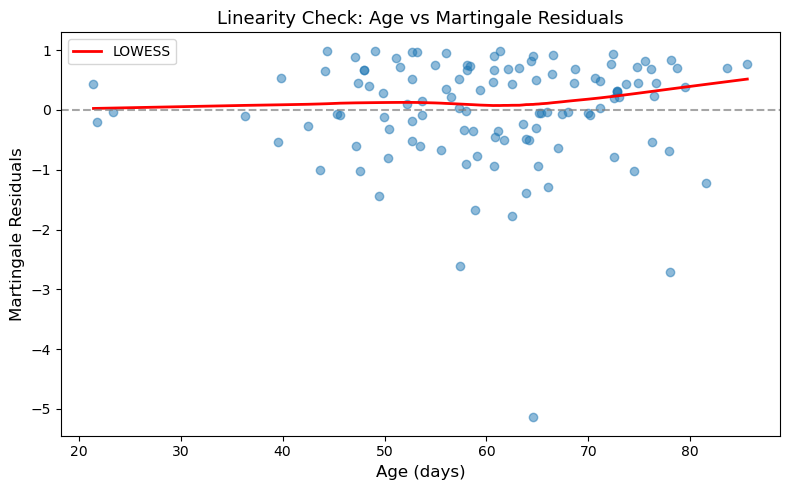

In [9]:
# ── Linearity Check: Martingale Residuals ────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from lifelines import CoxPHFitter
import statsmodels.api as sm

# --- Get Martingale residuals from null model (no covariates) ---
null_df = cox_adj_df[["OS.time", "event"]].copy()

cph_null = CoxPHFitter()
cph_null.fit(null_df, duration_col="OS.time", event_col="event")

martingale_resid = cph_adj.compute_residuals(cox_adj_df, kind="martingale")

# --- Plot Age vs Martingale Residuals ---
plt.figure(figsize=(8, 5))
plt.scatter(cox_adj_df["Age"], martingale_resid["martingale"], alpha=0.5)

# Lowess smoothing line
lowess = sm.nonparametric.lowess
smoothed = lowess(martingale_resid["martingale"], cox_adj_df["Age"], frac=0.75)
plt.plot(smoothed[:, 0], smoothed[:, 1], color="red", linewidth=2, label="LOWESS")

plt.axhline(y=0, linestyle="--", color="gray", alpha=0.7)
plt.xlabel("Age (days)", fontsize=12)
plt.ylabel("Martingale Residuals", fontsize=12)
plt.title("Linearity Check: Age vs Martingale Residuals", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ── Influential Observations Setup ──────────────────────────────────────────

print("Dataset shape:", cox_adj_df.shape)
print("\nIndex range:", cox_adj_df.index.min(), "to", cox_adj_df.index.max())

Dataset shape: (117, 7)

Index range: 19 to 597


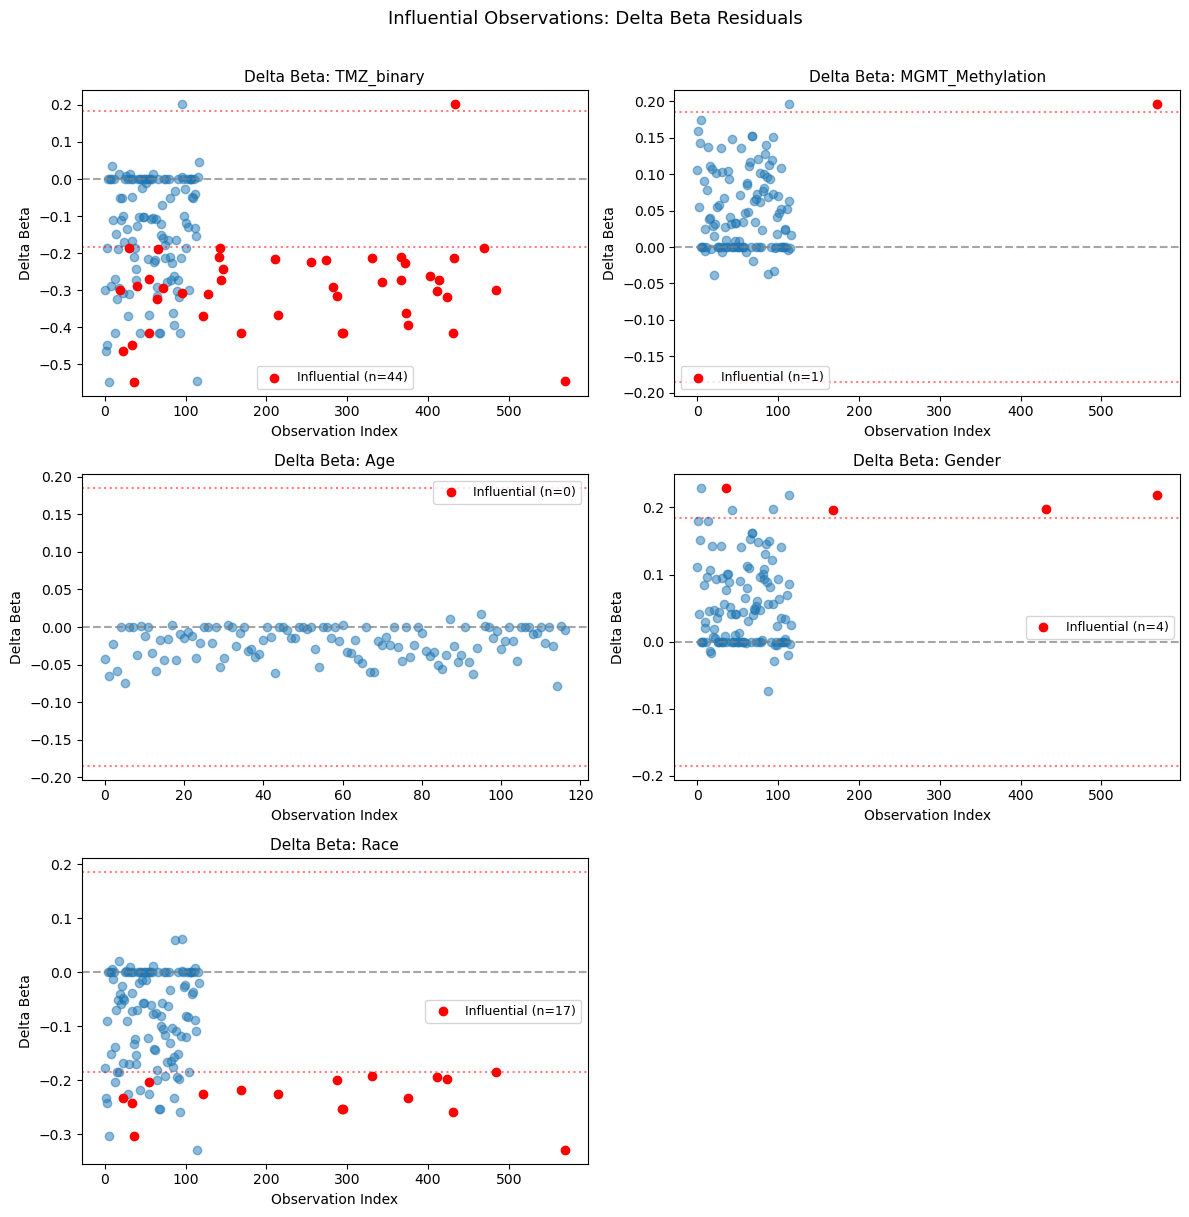


── Influential Observations per Covariate ───────────────────────────

TMZ_binary (n=44 influential):
     OS.time  event  TMZ_binary  MGMT_Methylation        Age  Gender  Race
19      24.0    1.0           1               1.0  61.305955       0   0.0
23      29.0    1.0           1               1.0  49.015743       0   1.0
30      36.0    1.0           0               1.0  72.462697       0   0.0
34      42.0    1.0           0               1.0  52.668036       0   0.0
36      45.0    1.0           0               1.0  44.369610       1   0.0
40      49.0    1.0           0               1.0  64.522930       0   0.0
54      77.0    1.0           0               1.0  66.581793       1   0.0
55      78.0    1.0           1               1.0  53.232033       1   1.0
65      88.0    1.0           1               1.0  60.722793       0   0.0
66      94.0    1.0           1               1.0  85.604381       1   0.0
72      98.0    1.0           1               1.0  56.024641       1   0

In [11]:
# --- Compute delta_beta residuals (equivalent to DFBETA) ---
dfbeta = cph_adj.compute_residuals(cox_adj_df, kind="delta_beta")

covariates = ["TMZ_binary", "MGMT_Methylation", "Age", "Gender", "Race"]

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, covariate in enumerate(covariates):
    ax = axes[i]
    ax.scatter(range(len(dfbeta)), dfbeta[covariate], alpha=0.5)
    ax.axhline(y=0, linestyle="--", color="gray", alpha=0.7)
    
    # --- Flag influential points (|delta_beta| > 2/sqrt(n)) ---
    threshold = 2 / np.sqrt(len(dfbeta))
    influential = dfbeta[np.abs(dfbeta[covariate]) > threshold]
    ax.scatter(
        influential.index,
        influential[covariate],
        color="red",
        label=f"Influential (n={len(influential)})",
        zorder=5
    )
    ax.axhline(y=threshold,  linestyle=":", color="red", alpha=0.5)
    ax.axhline(y=-threshold, linestyle=":", color="red", alpha=0.5)
    ax.set_title(f"Delta Beta: {covariate}", fontsize=11)
    ax.set_xlabel("Observation Index", fontsize=10)
    ax.set_ylabel("Delta Beta", fontsize=10)
    ax.legend(fontsize=9)

# --- Hide empty subplot ---
axes[-1].set_visible(False)

plt.suptitle("Influential Observations: Delta Beta Residuals", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# --- Print influential observations ---
print("\n── Influential Observations per Covariate ───────────────────────────")
for covariate in covariates:
    threshold = 2 / np.sqrt(len(dfbeta))
    influential = cox_adj_df[np.abs(dfbeta[covariate]) > threshold]
    print(f"\n{covariate} (n={len(influential)} influential):")
    print(influential[["OS.time", "event", "TMZ_binary", "MGMT_Methylation", "Age", "Gender", "Race"]])

In [12]:
print(merged_df.columns.tolist())

['sample', 'OS.time', 'OS', '_PATIENT', 'id', 'disease_type', 'case_id', 'submitter_id', 'primary_site', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'primary_site.project', 'project_id.project', 'disease_type.project', 'name.project', 'name.program.project', 'tissue_source_site_id.tissue_source_site', 'code.tissue_source_site', 'name.tissue_source_site', 'project.tissue_source_site', 'bcr_id.tissue_source_site', 'days_to_death.demographic', 'entity_submitter_id.annotations', 'notes.annotations', 'submitter_id.annotations', 'classification.annotations', 'entity_id.annotations', 'created_datetime.annotations', 'annotation_id.annotations', 'entity_type.annotations', 'updated_datetime.annotations', 'case_id.annotations', 'state.annotations', 'category.annotations', 'status.annotations', 'case_submitter_id.annotations', 'morpho

In [1]:
# ── RNA-seq Data Load and Merge ──────────────────────────────────────────────

# --- Load RNA-seq data ---
rna_df = pd.read_csv("TCGA_data/RNAseq_data.txt", sep="\t", index_col="Ensembl_ID")

# --- Strip version numbers from Ensembl IDs ---
rna_df.index = rna_df.index.str.split(".").str[0]

print("RNA-seq shape:", rna_df.shape)

# --- Key GBM genes and their Ensembl IDs (no version) ---
genes_of_interest = {
    "ENSG00000170430": "MGMT",
    "ENSG00000128052": "IDH1",
    "ENSG00000182054": "IDH2",
    "ENSG00000146648": "EGFR",
    "ENSG00000171862": "PTEN",
    "ENSG00000141510": "TP53",
    "ENSG00000164362": "TERT"
}

# --- Filter for genes of interest ---
available_genes = {k: v for k, v in genes_of_interest.items() 
                   if k in rna_df.index}

print("\nGenes found after stripping versions:")
print(available_genes)

# --- Subset and transpose ---
rna_subset = rna_df.loc[available_genes.keys()].T
rna_subset.columns = [available_genes[col] for col in rna_subset.columns]
rna_subset.index.name = "sample"
rna_subset = rna_subset.reset_index()

# --- Check sample ID format in both dataframes ---
print("\nRNA sample IDs (first 5):")
print(rna_subset["sample"].head().tolist())
print("\nmerged_df sample IDs (first 5):")
print(merged_df["sample"].head().tolist())

# --- Trim RNA sample IDs to match merged_df format ---
rna_subset["sample"] = rna_subset["sample"].str[:15]

print("\nRNA subset shape:", rna_subset.shape)
print(rna_subset.head())

# --- Reload merged_df fresh before merging to avoid column loss ---
merged_df = merged_df.merge(rna_subset, on="sample", how="inner")

print("\nMerged shape after RNA join:", merged_df.shape)
print("\nGenes available:")
found_genes = [g for g in available_genes.values() if g in merged_df.columns]
print(found_genes)
print(merged_df[found_genes].describe())

NameError: name 'pd' is not defined

In [14]:
# --- Check sample IDs and key columns ---
print("merged_df shape:", merged_df.shape)
print("\nSample IDs (first 10):")
print(merged_df["sample"].head(10).tolist())

print("\nAll columns:")
print(merged_df.columns.tolist())

print("RNA sample IDs (first 10):")
print(rna_subset["sample"].head(10).tolist())

merged_df shape: (0, 88)

Sample IDs (first 10):
[]

All columns:
['sample', 'OS.time', 'OS', '_PATIENT', 'id', 'disease_type', 'case_id', 'submitter_id', 'primary_site', 'race.demographic', 'gender.demographic', 'ethnicity.demographic', 'vital_status.demographic', 'age_at_index.demographic', 'days_to_birth.demographic', 'year_of_birth.demographic', 'year_of_death.demographic', 'primary_site.project', 'project_id.project', 'disease_type.project', 'name.project', 'name.program.project', 'tissue_source_site_id.tissue_source_site', 'code.tissue_source_site', 'name.tissue_source_site', 'project.tissue_source_site', 'bcr_id.tissue_source_site', 'days_to_death.demographic', 'entity_submitter_id.annotations', 'notes.annotations', 'submitter_id.annotations', 'classification.annotations', 'entity_id.annotations', 'created_datetime.annotations', 'annotation_id.annotations', 'entity_type.annotations', 'updated_datetime.annotations', 'case_id.annotations', 'state.annotations', 'category.annotation

In [15]:
# --- Step 1: Rebuild merged_df from scratch ---
survival_df = pd.read_csv("TCGA_data/survival_data.txt", sep="\t")
phenotype_df = pd.read_csv("TCGA_data/survival_full_set.csv")

merged_df = survival_df.merge(phenotype_df, on="sample", how="inner")

print("Fresh merged_df shape:", merged_df.shape)
print("Sample IDs (first 5):", merged_df["sample"].head().tolist())

Fresh merged_df shape: (599, 75)
Sample IDs (first 5): ['TCGA-12-0657-01A', 'TCGA-32-1977-01A', 'TCGA-19-1791-01A', 'TCGA-28-1757-01A', 'TCGA-19-2624-01A']


In [16]:
# --- Step 2: Trim merged_df sample IDs to 15 characters ---
merged_df["sample"] = merged_df["sample"].str[:15]

print("merged_df sample IDs (first 5):", merged_df["sample"].head().tolist())
print("RNA sample IDs (first 5):", rna_subset["sample"].head().tolist())

# --- Step 3: Check overlap before merging ---
overlap = set(merged_df["sample"]).intersection(set(rna_subset["sample"]))
print(f"\nOverlapping samples: {len(overlap)}")

# --- Step 4: Merge ---
merged_df = merged_df.merge(rna_subset, on="sample", how="inner")

print("\nMerged shape after RNA join:", merged_df.shape)
print("\nGene columns summary:")
genes = ["MGMT", "IDH1", "IDH2", "EGFR", "PTEN", "TP53", "TERT"]
print(merged_df[genes].describe())

merged_df sample IDs (first 5): ['TCGA-12-0657-01', 'TCGA-32-1977-01', 'TCGA-19-1791-01', 'TCGA-28-1757-01', 'TCGA-19-2624-01']
RNA sample IDs (first 5): ['TCGA-27-2521-01', 'TCGA-19-1390-01', 'TCGA-27-1830-01', 'TCGA-32-1970-01', 'TCGA-06-0190-01']

Overlapping samples: 155

Merged shape after RNA join: (160, 82)

Gene columns summary:
             MGMT        IDH1        IDH2        EGFR        PTEN        TP53  \
count  160.000000  160.000000  160.000000  160.000000  160.000000  160.000000   
mean     1.393800    2.417817    5.910396    5.874403    2.673972    4.070532   
std      0.612576    0.582550    0.445076    2.096836    0.452955    0.590101   
min      0.373509    0.961697    4.748128    2.140975    1.441643    1.962105   
25%      0.885921    2.112984    5.665929    4.067586    2.427089    3.736002   
50%      1.457061    2.415906    5.909274    5.928023    2.729052    4.090549   
75%      1.786860    2.752373    6.246034    7.639079    2.978536    4.410592   
max      2.82

In [17]:
# --- Re-apply all processing steps on fresh merged_df ---

# Event encoding
merged_df["event"] = merged_df["vital_status.demographic"].map({
    "Dead": 1,
    "Alive": 0
})

# Clean OS.time
merged_df["OS.time"] = pd.to_numeric(merged_df["OS.time"], errors="coerce")

# Age in years
merged_df["Age_years"] = merged_df["age_at_diagnosis.diagnoses"] / 365.25

# TMZ group
def classify_tmz(val):
    val_str = str(val).lower()
    if "tmz" in val_str or "temozolomide" in val_str:
        return "TMZ"
    else:
        return "Non-TMZ"

merged_df["TMZ_group"]  = merged_df["treatment_or_therapy.treatments.diagnoses"].apply(classify_tmz)
merged_df["TMZ_binary"] = (merged_df["TMZ_group"] == "TMZ").astype(int)

# Gender and Race encoding
merged_df["Gender_binary"] = merged_df["gender.demographic"].map({
    "male": 0, "female": 1
})
merged_df["Race_encoded"] = merged_df["race.demographic"].map({
    "white":                            0,
    "black or african american":        1,
    "asian":                            2,
    "american indian or alaska native": 3,
    "not reported":                     np.nan
})

# Methylation label
merged_df["Methylation_Label"] = merged_df["Methylation_Status"].map({
    1: "Methylated",
    0: "Unmethylated"
})

# Drop missing
merged_df = merged_df.dropna(subset=["OS.time", "event", "Methylation_Status",
                                      "Age_years", "Gender_binary", "TMZ_binary"])

print("Final dataset shape:", merged_df.shape)
print("\nTMZ group counts:")
print(merged_df["TMZ_group"].value_counts())
print("\nMethylation counts:")
print(merged_df["Methylation_Status"].value_counts())

Final dataset shape: (52, 89)

TMZ group counts:
TMZ_group
TMZ        40
Non-TMZ    12
Name: count, dtype: int64

Methylation counts:
Methylation_Status
1.0    48
0.0     4
Name: count, dtype: int64



── TMZ × Gene Interaction Summary ──────────────────────────────────
Gene    HR  CI_lower  CI_upper  p_value
MGMT 0.249     0.042     1.459 0.123218
IDH1 1.253     0.232     6.778 0.793204
IDH2 2.271     0.464    11.119 0.311437
EGFR 1.429     0.853     2.395 0.175451
PTEN 0.320     0.005    22.608 0.599716
TP53 5.610     1.517    20.742 0.009743
TERT 0.019     0.000 16343.461 0.570198


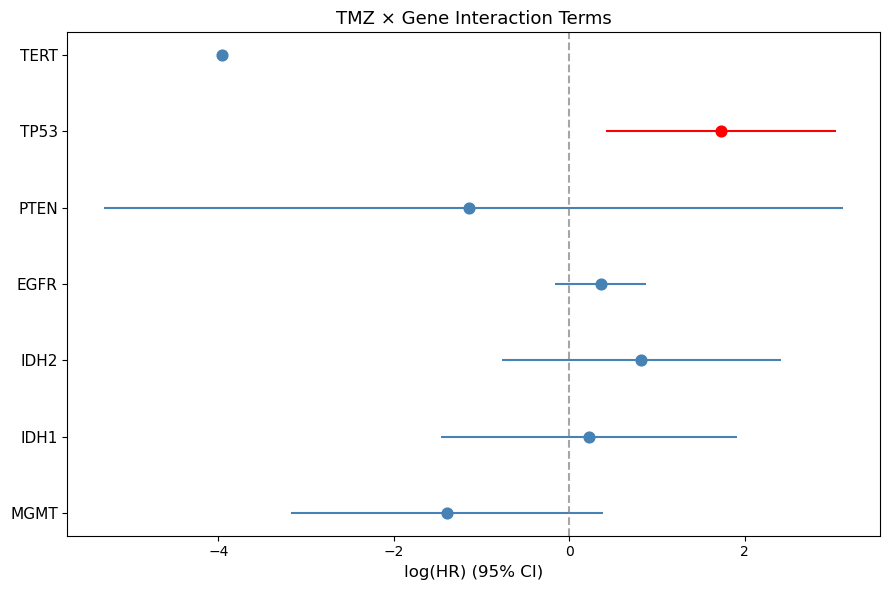

In [18]:
# ── TMZ × Gene Interaction Cox Models ───────────────────────────────────────
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

genes = ["MGMT", "IDH1", "IDH2", "EGFR", "PTEN", "TP53", "TERT"]
results_summary = []

for gene in genes:
    # --- Create interaction term ---
    merged_df[f"TMZ_x_{gene}"] = merged_df["TMZ_binary"] * merged_df[gene]

    # --- Build Cox dataframe ---
    cox_int_df = merged_df[[
        "OS.time", "event",
        "TMZ_binary",
        gene,
        f"TMZ_x_{gene}",
        "Methylation_Status",
        "Age_years",
        "Gender_binary"
    ]].dropna()

    # --- Fit model ---
    cph = CoxPHFitter()
    cph.fit(cox_int_df, duration_col="OS.time", event_col="event")

    # --- Extract interaction term ---
    interaction_term = f"TMZ_x_{gene}"
    hr    = cph.summary.loc[interaction_term, "exp(coef)"]
    lower = cph.summary.loc[interaction_term, "exp(coef) lower 95%"]
    upper = cph.summary.loc[interaction_term, "exp(coef) upper 95%"]
    pval  = cph.summary.loc[interaction_term, "p"]

    results_summary.append({
        "Gene":     gene,
        "HR":       round(hr, 3),
        "CI_lower": round(lower, 3),
        "CI_upper": round(upper, 3),
        "p_value":  pval
    })

# --- Summary table ---
results_df = pd.DataFrame(results_summary)
print("\n── TMZ × Gene Interaction Summary ──────────────────────────────────")
print(results_df.to_string(index=False))

# --- Forest plot of interaction terms ---
fig, ax = plt.subplots(figsize=(9, 6))

for i, row in results_df.iterrows():
    color = "red" if row["p_value"] < 0.05 else "steelblue"
    ax.scatter(np.log(row["HR"]), i, color=color, zorder=5, s=60)
    ax.hlines(i,
              np.log(row["CI_lower"]),
              np.log(row["CI_upper"]),
              color=color, linewidth=1.5)

ax.axvline(x=0, linestyle="--", color="gray", alpha=0.7)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["Gene"], fontsize=11)
ax.set_xlabel("log(HR) (95% CI)", fontsize=12)
ax.set_title("TMZ × Gene Interaction Terms", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
# ── TMZ × MGMT Interaction Setup ─────────────────────────────────────────────

# --- Create interaction term ---
merged_df["TMZ_x_MGMT"] = merged_df["TMZ_binary"] * merged_df["MGMT"]

# --- Build Cox dataframe ---
cox_mgmt_df = merged_df[[
    "OS.time", "event",
    "TMZ_binary",
    "MGMT",
    "TMZ_x_MGMT",
    "Methylation_Status",
    "Age_years",
    "Gender_binary"
]].dropna()

print("Dataset shape:", cox_mgmt_df.shape)
print("\nTMZ binary counts:")
print(cox_mgmt_df["TMZ_binary"].value_counts())
print("\nMGMT expression summary:")
print(cox_mgmt_df["MGMT"].describe())
print("\nInteraction term summary:")
print(cox_mgmt_df["TMZ_x_MGMT"].describe())

Dataset shape: (52, 8)

TMZ binary counts:
TMZ_binary
1    40
0    12
Name: count, dtype: int64

MGMT expression summary:
count    52.000000
mean      1.282943
std       0.496644
min       0.388906
25%       0.871920
50%       1.392750
75%       1.675783
max       2.141956
Name: MGMT, dtype: float64

Interaction term summary:
count    52.000000
mean      0.968323
std       0.694980
min       0.000000
25%       0.447451
50%       0.917092
75%       1.523950
max       2.141956
Name: TMZ_x_MGMT, dtype: float64


<lifelines.CoxPHFitter: fitted with 52 total observations, 14 right-censored observations>
             duration col = 'OS.time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 52
number of events observed = 38
   partial log-likelihood = -99.67
         time fit was run = 2026-02-28 12:07:03 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
TMZ_binary          1.61      5.02      1.32           -0.98            4.21                0.38               67.21
MGMT                2.07      7.89      0.76            0.57            3.56                1.78               35.05
TMZ_x_MGMT         -1.39      0.25      0.90           -3.16            0.38                0.04                1.46
Methylation_Status -0.00      1.00      0.76           -1.49            1.49                0.23                4.42
Age_years           0.05      1.05      0.02            0.01            0.10                1.01                1.10
Gender_binary       0.48      1.62      0.48           -0.46            1.42                0.63                4.15

                    cmp to     z    p  -log2(p)
covariate                                      
TMZ_binary            0.00  1.22 0.22      2.17
MGMT                  0.00  2.72 0.01      7.24
TMZ_x_MGMT            0.00 -1.54 0.12      3.02
Methylation_Status    0.00 -0.00 1.00      0.00
Age_years             0.00  2.25 0.02      5.35
Gender_binary         0.00  1.00 0.32      1.66
---
Concordance = 0.72
Partial AIC = 211.35
log-likelihood ratio test = 21.60 on 6 df
-log2(p) of ll-ratio test = 9.45

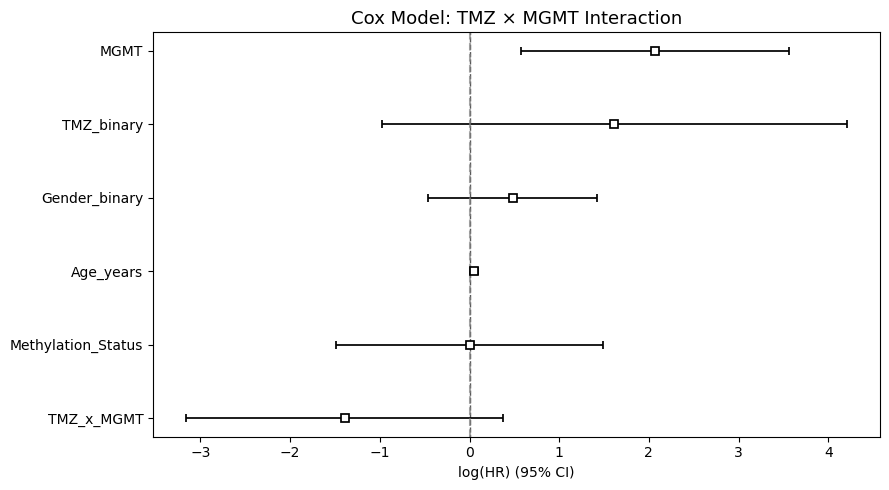

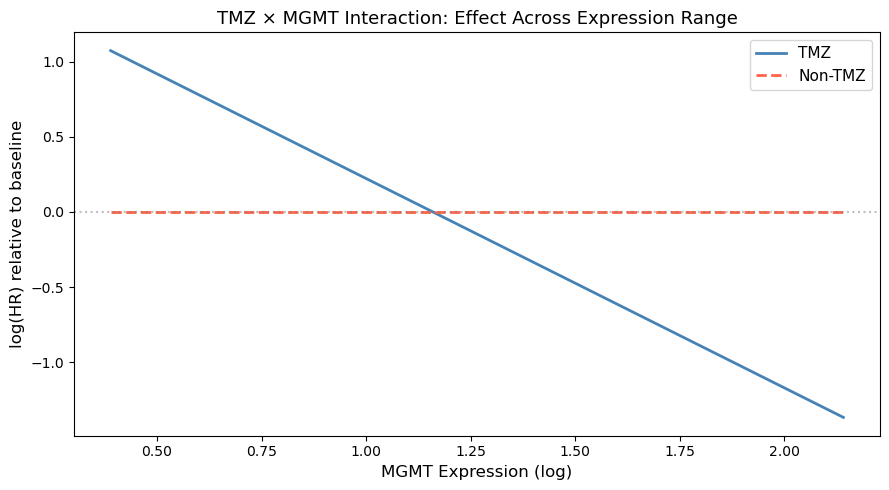

In [20]:
# ── TMZ × MGMT Interaction Cox Model ─────────────────────────────────────────
from lifelines import CoxPHFitter
import matplotlib.pyplot as plt
import numpy as np

cph_mgmt = CoxPHFitter()
cph_mgmt.fit(cox_mgmt_df, duration_col="OS.time", event_col="event")

cph_mgmt.print_summary()

# --- Forest plot ---
plt.figure(figsize=(9, 5))
cph_mgmt.plot()
plt.title("Cox Model: TMZ × MGMT Interaction", fontsize=13)
plt.axvline(x=0, linestyle="--", color="gray", alpha=0.7)
plt.tight_layout()
plt.show()

# --- Visualize interaction effect across MGMT expression range ---
mgmt_range = np.linspace(
    cox_mgmt_df["MGMT"].min(),
    cox_mgmt_df["MGMT"].max(), 
    100
)

# TMZ vs Non-TMZ predicted log hazard across MGMT expression
log_hr_tmz     = (cph_mgmt.params_["TMZ_binary"] + 
                  cph_mgmt.params_["TMZ_x_MGMT"] * mgmt_range)
log_hr_non_tmz = np.zeros(len(mgmt_range))

plt.figure(figsize=(9, 5))
plt.plot(mgmt_range, log_hr_tmz,     color="steelblue", label="TMZ",     linewidth=2)
plt.plot(mgmt_range, log_hr_non_tmz, color="tomato",    label="Non-TMZ", linewidth=2, linestyle="--")
plt.axhline(y=0, linestyle=":", color="gray", alpha=0.5)
plt.xlabel("MGMT Expression (log)", fontsize=12)
plt.ylabel("log(HR) relative to baseline", fontsize=12)
plt.title("TMZ × MGMT Interaction: Effect Across Expression Range", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

Full RNA-seq shape: (60660, 175)

First few Ensembl IDs:
['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419', 'ENSG00000000457', 'ENSG00000000460']

Variance summary:
count    60660.000000
mean         0.131000
std          0.299384
min          0.000000
25%          0.001044
50%          0.019290
75%          0.135725
max          8.388631
dtype: float64


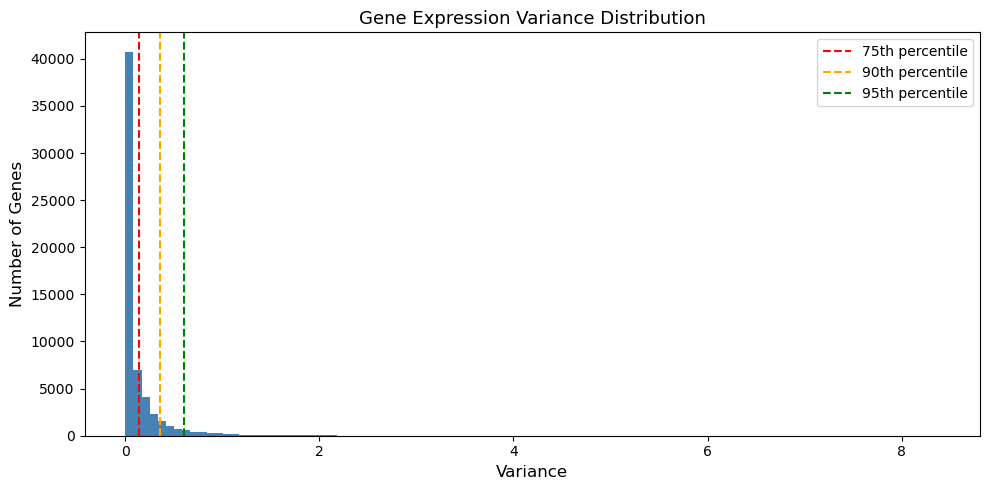


Genes above variance thresholds:
  Top 25% (variance > 0.136): 15165 genes
  Top 9% (variance > 0.356): 6066 genes
  Top 5% (variance > 0.605): 3033 genes


In [21]:
# ── Variance Filtering Setup ─────────────────────────────────────────────────
import pandas as pd
import numpy as np

# --- Reload full RNA-seq data ---
rna_df = pd.read_csv("TCGA_data/RNAseq_data.txt", sep="\t", index_col="Ensembl_ID")

# --- Strip version numbers ---
rna_df.index = rna_df.index.str.split(".").str[0]

print("Full RNA-seq shape:", rna_df.shape)
print("\nFirst few Ensembl IDs:")
print(rna_df.index[:5].tolist())

# --- Calculate variance across all samples for each gene ---
gene_variance = rna_df.var(axis=1)

print("\nVariance summary:")
print(gene_variance.describe())

# --- Plot variance distribution ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(gene_variance, bins=100, color="steelblue", edgecolor="none")
plt.axvline(x=gene_variance.quantile(0.75), 
            color="red", linestyle="--", label="75th percentile")
plt.axvline(x=gene_variance.quantile(0.90), 
            color="orange", linestyle="--", label="90th percentile")
plt.axvline(x=gene_variance.quantile(0.95), 
            color="green", linestyle="--", label="95th percentile")
plt.xlabel("Variance", fontsize=12)
plt.ylabel("Number of Genes", fontsize=12)
plt.title("Gene Expression Variance Distribution", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("\nGenes above variance thresholds:")
for q in [0.75, 0.90, 0.95]:
    threshold = gene_variance.quantile(q)
    n_genes = (gene_variance > threshold).sum()
    print(f"  Top {int((1-q)*100)}% (variance > {threshold:.3f}): {n_genes} genes")

In [22]:
# ── Apply Variance Filter ────────────────────────────────────────────────────

# --- Choose threshold (top 25% most variable genes) ---
variance_threshold = gene_variance.quantile(0.75)
high_var_genes = gene_variance[gene_variance > variance_threshold].index

print(f"Variance threshold: {variance_threshold:.3f}")
print(f"Genes retained after filtering: {len(high_var_genes)}")

# --- Filter RNA-seq data ---
rna_filtered = rna_df.loc[high_var_genes]

print("\nFiltered RNA-seq shape:", rna_filtered.shape)

# --- Transpose and clean sample IDs ---
rna_filtered = rna_filtered.T
rna_filtered.index.name = "sample"
rna_filtered = rna_filtered.reset_index()
rna_filtered["sample"] = rna_filtered["sample"].str[:15]

print("\nFiltered RNA sample IDs (first 5):")
print(rna_filtered["sample"].head().tolist())

# --- Check overlap with merged_df ---
overlap = set(merged_df["sample"]).intersection(set(rna_filtered["sample"]))
print(f"\nOverlapping samples with merged_df: {len(overlap)}")

print("\nFiltered dataset ready for downstream analysis")
print("Shape:", rna_filtered.shape)

Variance threshold: 0.136
Genes retained after filtering: 15165

Filtered RNA-seq shape: (15183, 175)

Filtered RNA sample IDs (first 5):
['TCGA-27-2521-01', 'TCGA-19-1390-01', 'TCGA-27-1830-01', 'TCGA-32-1970-01', 'TCGA-06-0190-01']

Overlapping samples with merged_df: 48

Filtered dataset ready for downstream analysis
Shape: (175, 15184)


In [23]:
# ── Univariate Cox Screening Setup ───────────────────────────────────────────
import pandas as pd
import numpy as np

# --- Rebuild merged RNA + clinical dataframe ---
survival_df  = pd.read_csv("TCGA_data/survival_data.txt", sep="\t")
phenotype_df = pd.read_csv("TCGA_data/survival_full_set.csv")

merged_df = survival_df.merge(phenotype_df, on="sample", how="inner")

# --- Re-apply processing ---
merged_df["event"] = merged_df["vital_status.demographic"].map({
    "Dead": 1, "Alive": 0
})
merged_df["OS.time"]   = pd.to_numeric(merged_df["OS.time"], errors="coerce")
merged_df["Age_years"] = merged_df["age_at_diagnosis.diagnoses"] / 365.25
merged_df["TMZ_binary"] = merged_df[
    "treatment_or_therapy.treatments.diagnoses"
].apply(lambda x: 1 if "tmz" in str(x).lower() or 
        "temozolomide" in str(x).lower() else 0)
merged_df["Gender_binary"] = merged_df["gender.demographic"].map({
    "male": 0, "female": 1
})

merged_df = merged_df.dropna(subset=["OS.time", "event", 
                                      "Methylation_Status", 
                                      "Age_years", "Gender_binary"])

# --- Trim sample IDs ---
merged_df["sample"] = merged_df["sample"].str[:15]

# --- Load and filter RNA-seq ---
rna_df = pd.read_csv("TCGA_data/RNAseq_data.txt", sep="\t", index_col="Ensembl_ID")
rna_df.index = rna_df.index.str.split(".").str[0]

# --- Apply variance filter (top 25%) ---
gene_variance     = rna_df.var(axis=1)
variance_threshold = gene_variance.quantile(0.75)
high_var_genes    = gene_variance[gene_variance > variance_threshold].index
rna_filtered      = rna_df.loc[high_var_genes].T
rna_filtered.index.name = "sample"
rna_filtered      = rna_filtered.reset_index()
rna_filtered["sample"] = rna_filtered["sample"].str[:15]

# --- Merge ---
merged_df = merged_df.merge(rna_filtered, on="sample", how="inner")

print("Final merged shape:", merged_df.shape)
print("Gene columns available:", len(high_var_genes))

# --- Build survival dataframe for screening ---
gene_cols = high_var_genes.tolist()
cox_screen_df = merged_df[["OS.time", "event"] + 
                           [g for g in gene_cols if g in merged_df.columns]].dropna()

print("\nCox screening dataframe shape:", cox_screen_df.shape)

Final merged shape: (52, 15262)
Gene columns available: 15165

Cox screening dataframe shape: (52, 15185)


Processing gene 0/15183...
Processing gene 1000/15183...
Processing gene 2000/15183...
Processing gene 3000/15183...
Processing gene 4000/15183...
Processing gene 5000/15183...
Processing gene 6000/15183...
Processing gene 7000/15183...
Processing gene 8000/15183...
Processing gene 9000/15183...
Processing gene 10000/15183...
Processing gene 11000/15183...
Processing gene 12000/15183...
Processing gene 13000/15183...
Processing gene 14000/15183...


/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))
/opt/anaconda3/lib/python3.12/site-packages/lifelines/fitters/coxph_fitter.py:1679: RuntimeWarning: overflow encountered in exp
  scores = weights * exp(dot(X, beta))


Processing gene 15000/15183...

Total genes screened: 15143
Significant after FDR correction (q < 0.05): 112

Top 20 genes by p-value:
           Gene     HR  CI_lower  CI_upper      p_value  p_adjusted  significant
ENSG00000167779  1.929     1.505     2.471 2.048301e-07    0.003102         True
ENSG00000034152  8.682     3.474    21.698 3.752244e-06    0.016483         True
ENSG00000132692  0.551     0.427     0.710 4.067788e-06    0.016483         True
ENSG00000008283  6.622     2.937    14.929 5.177683e-06    0.016483         True
ENSG00000095752  3.390     1.995     5.760 6.347166e-06    0.016483         True
ENSG00000235169 10.042     3.677    27.421 6.771979e-06    0.016483         True
ENSG00000186832 42.494     8.210   219.938 7.820527e-06    0.016483         True
ENSG00000108688  2.531     1.681     3.810 8.708010e-06    0.016483         True
ENSG00000253161  3.275     1.935     5.542 9.881682e-06    0.016626         True
ENSG00000253746  8.181     3.161    21.171 1.474990e-05

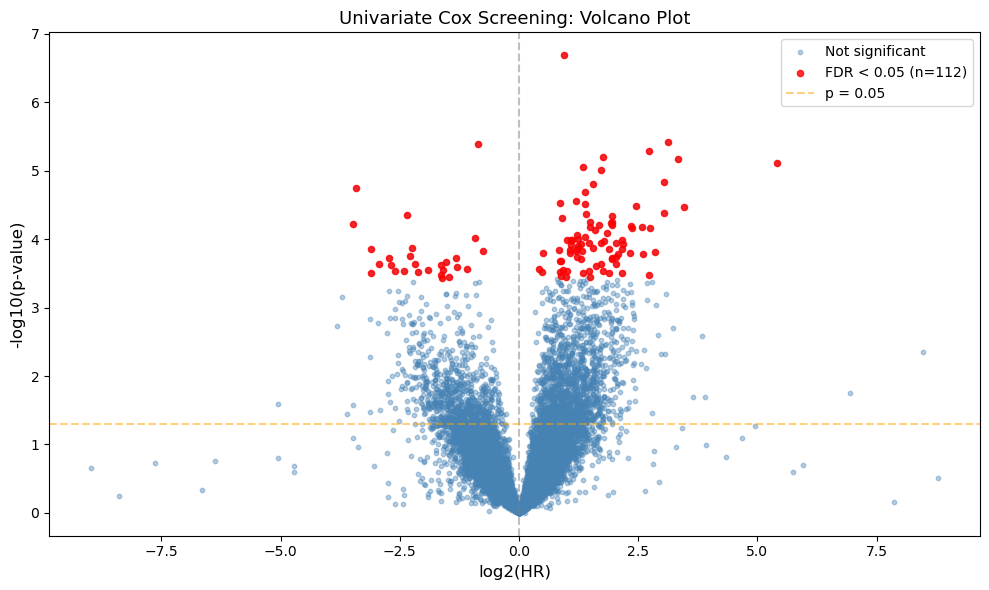


Results saved to TCGA_data/univariate_cox_results.csv


In [24]:
# ── Univariate Cox Screening ─────────────────────────────────────────────────
from lifelines import CoxPHFitter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gene_cols = [col for col in cox_screen_df.columns 
             if col not in ["OS.time", "event"]]

results = []

for i, gene in enumerate(gene_cols):
    if i % 1000 == 0:
        print(f"Processing gene {i}/{len(gene_cols)}...")
    try:
        cox_df = cox_screen_df[["OS.time", "event", gene]].dropna()
        
        # Skip genes with no variance
        if cox_df[gene].std() == 0:
            continue
            
        cph = CoxPHFitter()
        cph.fit(cox_df, duration_col="OS.time", event_col="event")
        
        hr    = cph.summary.loc[gene, "exp(coef)"]
        lower = cph.summary.loc[gene, "exp(coef) lower 95%"]
        upper = cph.summary.loc[gene, "exp(coef) upper 95%"]
        pval  = cph.summary.loc[gene, "p"]
        
        results.append({
            "Gene":     gene,
            "HR":       round(hr, 3),
            "CI_lower": round(lower, 3),
            "CI_upper": round(upper, 3),
            "p_value":  pval
        })
    except Exception:
        continue

# --- Build results dataframe ---
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("p_value")

# --- Apply FDR correction (Benjamini-Hochberg) ---
from statsmodels.stats.multitest import multipletests

rejected, p_adjusted, _, _ = multipletests(
    results_df["p_value"], method="fdr_bh"
)
results_df["p_adjusted"] = p_adjusted
results_df["significant"] = rejected

print(f"\nTotal genes screened: {len(results_df)}")
print(f"Significant after FDR correction (q < 0.05): {results_df['significant'].sum()}")
print("\nTop 20 genes by p-value:")
print(results_df.head(20).to_string(index=False))

# --- Volcano plot ---
plt.figure(figsize=(10, 6))
plt.scatter(
    np.log2(results_df["HR"]),
    -np.log10(results_df["p_value"]),
    alpha=0.4, color="steelblue", s=10, label="Not significant"
)
# Highlight significant genes
sig = results_df[results_df["significant"]]
plt.scatter(
    np.log2(sig["HR"]),
    -np.log10(sig["p_value"]),
    alpha=0.8, color="red", s=20, label=f"FDR < 0.05 (n={len(sig)})"
)
plt.axvline(x=0,    linestyle="--", color="gray", alpha=0.5)
plt.axhline(y=-np.log10(0.05), linestyle="--", color="orange", 
            alpha=0.5, label="p = 0.05")
plt.xlabel("log2(HR)", fontsize=12)
plt.ylabel("-log10(p-value)", fontsize=12)
plt.title("Univariate Cox Screening: Volcano Plot", fontsize=13)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# --- Save results ---
results_df.to_csv("TCGA_data/univariate_cox_results.csv", index=False)
print("\nResults saved to TCGA_data/univariate_cox_results.csv")

In [25]:
# ── Biological Pre-selection: DNA Repair Genes ───────────────────────────────

# --- Curated DNA repair gene list relevant to GBM and TMZ response ---
dna_repair_genes = {
    # Direct TMZ targets
    "ENSG00000170430": "MGMT",       # O6-methylguanine repair
    
    # Mismatch repair (MMR)
    "ENSG00000095002": "MSH2",
    "ENSG00000116062": "MSH6",
    "ENSG00000079246": "MSH3",
    "ENSG00000095564": "MLH1",
    "ENSG00000122512": "PMS2",
    "ENSG00000100393": "PMS1",
    
    # Base excision repair (BER)
    "ENSG00000132781": "MUTYH",
    "ENSG00000077097": "TOP2B",
    "ENSG00000170175": "SMUG1",
    "ENSG00000162517": "PARP1",
    "ENSG00000043355": "PARP2",
    "ENSG00000111057": "UNG",
    "ENSG00000107485": "XRCC1",
    
    # Nucleotide excision repair (NER)
    "ENSG00000104884": "ERCC2",
    "ENSG00000163931": "ERCC3",
    "ENSG00000136936": "ERCC4",
    "ENSG00000134899": "ERCC5",
    "ENSG00000175595": "ERCC6",
    "ENSG00000049167": "ERCC8",
    
    # Double strand break repair (DSBR)
    "ENSG00000012048": "BRCA1",
    "ENSG00000139618": "BRCA2",
    "ENSG00000141510": "TP53",
    "ENSG00000171862": "PTEN",
    "ENSG00000149311": "ATM",
    "ENSG00000167986": "ATR",
    "ENSG00000128052": "IDH1",
    "ENSG00000182054": "IDH2",
    
    # Chromatin remodeling / epigenetic
    "ENSG00000164362": "TERT",
    "ENSG00000146648": "EGFR"
}

print(f"Total DNA repair genes in list: {len(dna_repair_genes)}")

# --- Check which are available in RNA-seq data ---
rna_df_check = pd.read_csv("TCGA_data/RNAseq_data.txt", sep="\t", index_col="Ensembl_ID")
rna_df_check.index = rna_df_check.index.str.split(".").str[0]

available = {k: v for k, v in dna_repair_genes.items() if k in rna_df_check.index}
missing   = {k: v for k, v in dna_repair_genes.items() if k not in rna_df_check.index}

print(f"\nGenes found in RNA-seq data: {len(available)}")
print(f"Genes not found: {len(missing)}")

if missing:
    print("\nMissing genes:")
    for k, v in missing.items():
        print(f"  {v} ({k})")

Total DNA repair genes in list: 30

Genes found in RNA-seq data: 30
Genes not found: 0


In [26]:
# ── Extract DNA Repair Genes and Merge ───────────────────────────────────────

# --- Subset RNA-seq for DNA repair genes ---
rna_repair = rna_df_check.loc[list(available.keys())].T
rna_repair.columns = [available[col] for col in rna_repair.columns]
rna_repair.index.name = "sample"
rna_repair = rna_repair.reset_index()
rna_repair["sample"] = rna_repair["sample"].str[:15]

print("DNA repair RNA subset shape:", rna_repair.shape)
print("\nGenes included:")
print(rna_repair.columns[1:].tolist())

# --- Rebuild clean merged_df ---
survival_df  = pd.read_csv("TCGA_data/survival_data.txt", sep="\t")
phenotype_df = pd.read_csv("TCGA_data/survival_full_set.csv")
merged_df    = survival_df.merge(phenotype_df, on="sample", how="inner")

# --- Re-apply processing ---
merged_df["event"] = merged_df["vital_status.demographic"].map({
    "Dead": 1, "Alive": 0
})
merged_df["OS.time"]    = pd.to_numeric(merged_df["OS.time"], errors="coerce")
merged_df["Age_years"]  = merged_df["age_at_diagnosis.diagnoses"] / 365.25
merged_df["TMZ_binary"] = merged_df[
    "treatment_or_therapy.treatments.diagnoses"
].apply(lambda x: 1 if "tmz" in str(x).lower() or
        "temozolomide" in str(x).lower() else 0)
merged_df["Gender_binary"] = merged_df["gender.demographic"].map({
    "male": 0, "female": 1
})
merged_df = merged_df.dropna(subset=["OS.time", "event",
                                      "Methylation_Status",
                                      "Age_years", "Gender_binary"])
merged_df["sample"] = merged_df["sample"].str[:15]

# --- Merge with DNA repair genes ---
merged_df = merged_df.merge(rna_repair, on="sample", how="inner")

print("\nFinal merged shape:", merged_df.shape)
print("\nDNA repair gene expression summary:")
gene_names = list(available.values())
print(merged_df[gene_names].describe())

DNA repair RNA subset shape: (175, 31)

Genes included:
['MGMT', 'MSH2', 'MSH6', 'MSH3', 'MLH1', 'PMS2', 'PMS1', 'MUTYH', 'TOP2B', 'SMUG1', 'PARP1', 'PARP2', 'UNG', 'XRCC1', 'ERCC2', 'ERCC3', 'ERCC4', 'ERCC5', 'ERCC6', 'ERCC8', 'BRCA1', 'BRCA2', 'TP53', 'PTEN', 'ATM', 'ATR', 'IDH1', 'IDH2', 'TERT', 'EGFR']

Final merged shape: (52, 109)

DNA repair gene expression summary:
            MGMT       MSH2       MSH6       MSH3       MLH1       PMS2  \
count  52.000000  52.000000  52.000000  52.000000  52.000000  52.000000   
mean    1.282943   2.043960   2.714423   5.834741   2.051875   2.305705   
std     0.496644   0.337381   0.424603   0.264288   0.453084   0.349484   
min     0.388906   1.370778   1.531619   5.361063   1.111499   1.419593   
25%     0.871920   1.837962   2.423267   5.667672   1.800496   2.047865   
50%     1.392750   2.027188   2.676093   5.805814   1.995231   2.289350   
75%     1.675783   2.186137   3.016789   5.975699   2.194552   2.497336   
max     2.141956   3.047

Genes screened: 30
Significant after FDR (q < 0.05): 1

Full results:
 Gene    HR  CI_lower  CI_upper  p_value  p_adjusted  significant
  UNG 1.688     1.219     2.336 0.001603    0.048105         True
ERCC5 0.005     0.000     0.298 0.011236    0.149629        False
 MGMT 2.407     1.186     4.882 0.014963    0.149629        False
TOP2B 0.432     0.207     0.902 0.025512    0.191340        False
ERCC8 0.135     0.016     1.158 0.067841    0.370210        False
 IDH2 0.458     0.191     1.096 0.079512    0.370210        False
 EGFR 0.847     0.701     1.024 0.086382    0.370210        False
  ATR 0.391     0.126     1.214 0.104295    0.391105        False
XRCC1 1.535     0.887     2.657 0.125426    0.418086        False
  ATM 0.517     0.199     1.342 0.175300    0.461003        False
 MLH1 0.572     0.251     1.306 0.184908    0.461003        False
ERCC6 0.425     0.118     1.530 0.190547    0.461003        False
BRCA2 0.453     0.126     1.629 0.225285    0.461003        False
 PTEN 

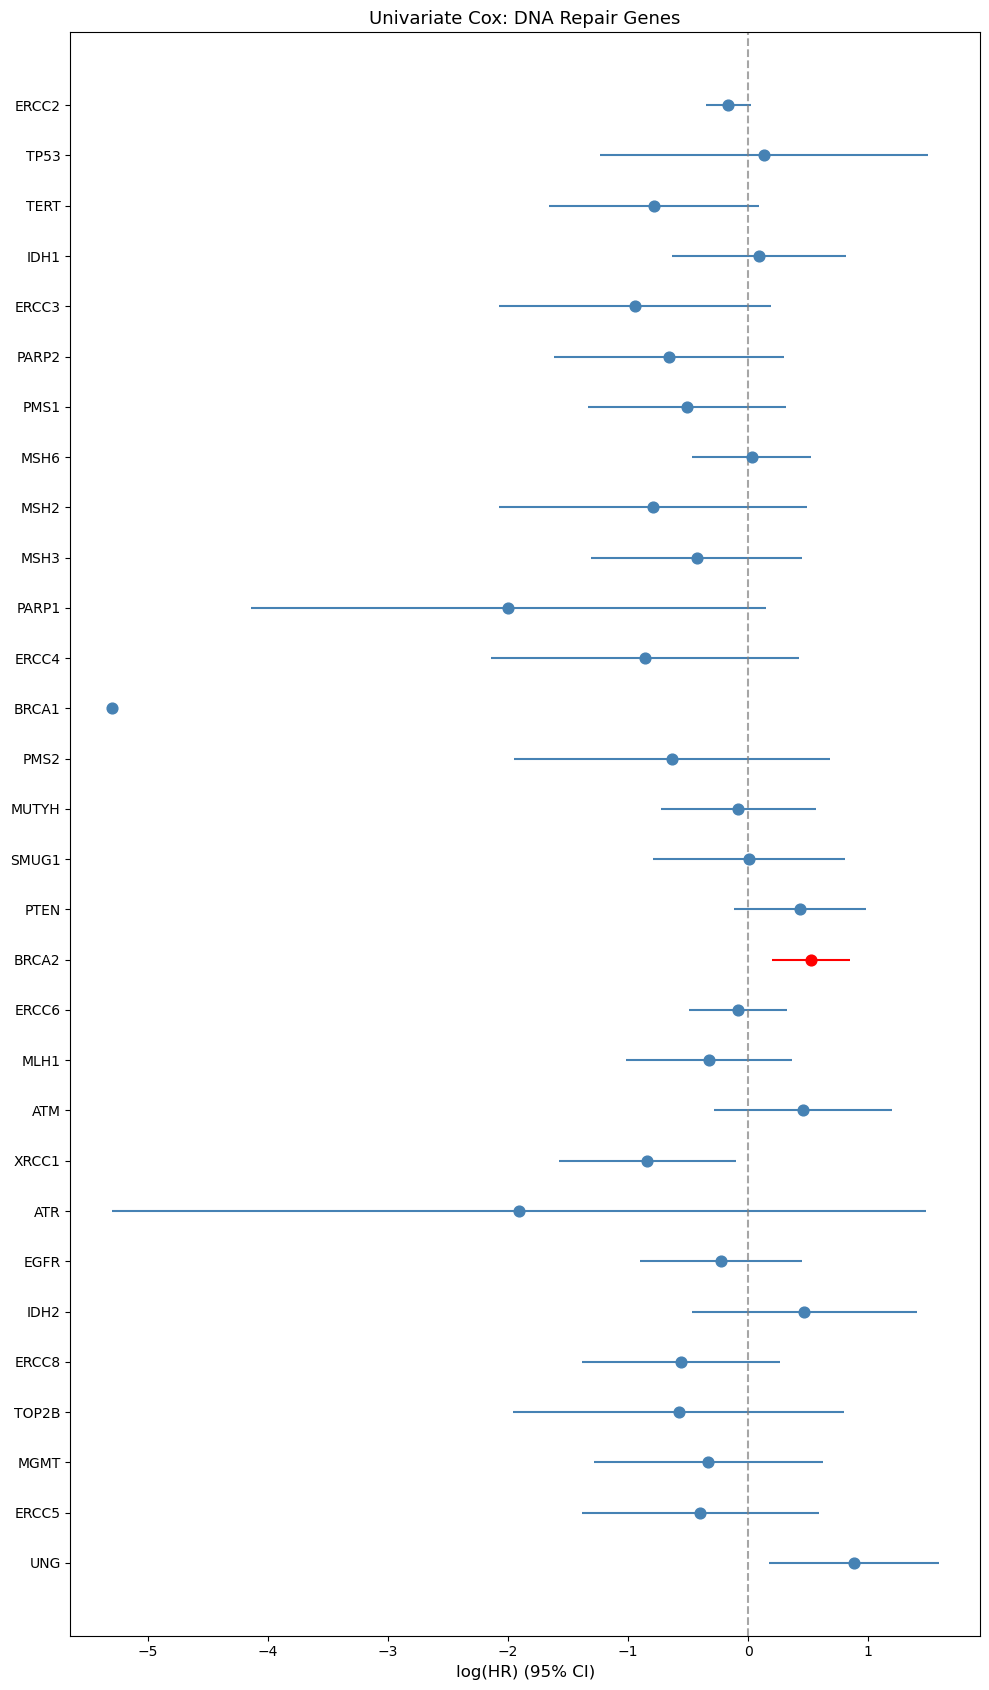


Results saved to TCGA_data/dna_repair_cox_results.csv


In [27]:
# ── Univariate Cox: DNA Repair Genes ─────────────────────────────────────────
from lifelines import CoxPHFitter
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import numpy as np

gene_names = [g for g in list(available.values()) if g in merged_df.columns]
results    = []

for gene in gene_names:
    try:
        cox_df = merged_df[["OS.time", "event", gene]].dropna()
        if cox_df[gene].std() == 0:
            continue
        cph = CoxPHFitter()
        cph.fit(cox_df, duration_col="OS.time", event_col="event")

        results.append({
            "Gene":     gene,
            "HR":       round(cph.summary.loc[gene, "exp(coef)"], 3),
            "CI_lower": round(cph.summary.loc[gene, "exp(coef) lower 95%"], 3),
            "CI_upper": round(cph.summary.loc[gene, "exp(coef) upper 95%"], 3),
            "p_value":  cph.summary.loc[gene, "p"]
        })
    except Exception:
        continue

# --- Results dataframe ---
results_df = pd.DataFrame(results).sort_values("p_value")

# --- FDR correction ---
rejected, p_adjusted, _, _ = multipletests(
    results_df["p_value"], method="fdr_bh"
)
results_df["p_adjusted"] = p_adjusted
results_df["significant"] = rejected

print(f"Genes screened: {len(results_df)}")
print(f"Significant after FDR (q < 0.05): {results_df['significant'].sum()}")
print("\nFull results:")
print(results_df.to_string(index=False))

# --- Forest plot ---
fig, ax = plt.subplots(figsize=(10, len(results_df) * 0.5 + 2))

for i, row in results_df.iterrows():
    color = "red" if row["significant"] else "steelblue"
    ax.scatter(np.log(row["HR"]), i, color=color, zorder=5, s=60)
    ax.hlines(i,
              np.log(row["CI_lower"]),
              np.log(row["CI_upper"]),
              color=color, linewidth=1.5)

ax.axvline(x=0, linestyle="--", color="gray", alpha=0.7)
ax.set_yticks(range(len(results_df)))
ax.set_yticklabels(results_df["Gene"], fontsize=10)
ax.set_xlabel("log(HR) (95% CI)", fontsize=12)
ax.set_title("Univariate Cox: DNA Repair Genes", fontsize=13)
plt.tight_layout()
plt.show()

# --- Save ---
results_df.to_csv("TCGA_data/dna_repair_cox_results.csv", index=False)
print("\nResults saved to TCGA_data/dna_repair_cox_results.csv")

In [28]:
# ── PCA Setup ────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Rebuild variance-filtered RNA-seq ---
rna_df = pd.read_csv("TCGA_data/RNAseq_data.txt", sep="\t", index_col="Ensembl_ID")
rna_df.index = rna_df.index.str.split(".").str[0]

gene_variance      = rna_df.var(axis=1)
variance_threshold = gene_variance.quantile(0.75)
high_var_genes     = gene_variance[gene_variance > variance_threshold].index
rna_filtered       = rna_df.loc[high_var_genes].T
rna_filtered.index.name = "sample"
rna_filtered       = rna_filtered.reset_index()
rna_filtered["sample"] = rna_filtered["sample"].str[:15]

# --- Rebuild merged_df ---
survival_df  = pd.read_csv("TCGA_data/survival_data.txt", sep="\t")
phenotype_df = pd.read_csv("TCGA_data/survival_full_set.csv")
merged_df    = survival_df.merge(phenotype_df, on="sample", how="inner")

merged_df["event"] = merged_df["vital_status.demographic"].map({
    "Dead": 1, "Alive": 0
})
merged_df["OS.time"]    = pd.to_numeric(merged_df["OS.time"], errors="coerce")
merged_df["Age_years"]  = merged_df["age_at_diagnosis.diagnoses"] / 365.25
merged_df["TMZ_binary"] = merged_df[
    "treatment_or_therapy.treatments.diagnoses"
].apply(lambda x: 1 if "tmz" in str(x).lower() or
        "temozolomide" in str(x).lower() else 0)
merged_df["Gender_binary"] = merged_df["gender.demographic"].map({
    "male": 0, "female": 1
})
merged_df = merged_df.dropna(subset=["OS.time", "event",
                                      "Methylation_Status",
                                      "Age_years", "Gender_binary"])
merged_df["sample"] = merged_df["sample"].str[:15]

# --- Merge ---
merged_df = merged_df.merge(rna_filtered, on="sample", how="inner")

print("Merged shape:", merged_df.shape)

# --- Extract gene expression matrix ---
gene_cols  = [col for col in rna_filtered.columns if col != "sample"]
gene_cols  = [col for col in gene_cols if col in merged_df.columns]
X          = merged_df[gene_cols].values

print(f"\nGene expression matrix shape: {X.shape}")
print(f"Samples: {X.shape[0]}, Genes: {X.shape[1]}")

# --- Standardize ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\nStandardization complete")

Merged shape: (52, 15262)

Gene expression matrix shape: (52, 15219)
Samples: 52, Genes: 15219

Standardization complete


PCs needed to explain 80% variance: 21
Variance explained by top 10 PCs: 0.628
Variance explained by top 20 PCs: 0.797


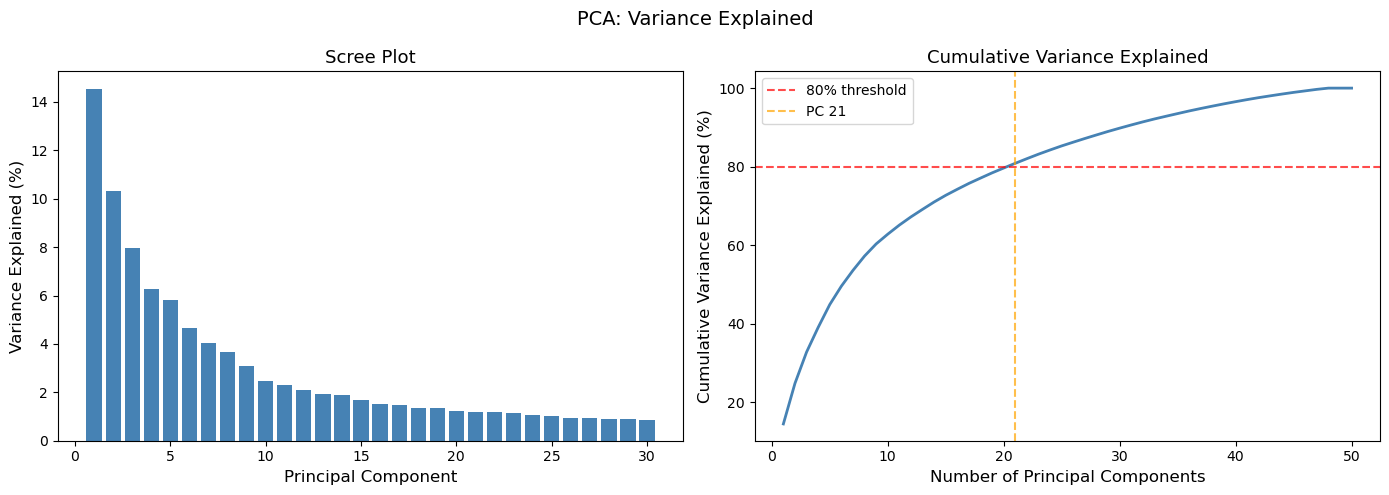

In [29]:
# ── PCA: Scree Plot and Variance Explained ───────────────────────────────────

# --- Fit full PCA first to see variance explained ---
pca_full = PCA()
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_80 = np.argmax(cumvar >= 0.80) + 1

print(f"PCs needed to explain 80% variance: {n_components_80}")
print(f"Variance explained by top 10 PCs: {cumvar[9]:.3f}")
print(f"Variance explained by top 20 PCs: {cumvar[19]:.3f}")

# --- Scree plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, 31),
            pca_full.explained_variance_ratio_[:30] * 100,
            color="steelblue", edgecolor="none")
axes[0].set_xlabel("Principal Component", fontsize=12)
axes[0].set_ylabel("Variance Explained (%)", fontsize=12)
axes[0].set_title("Scree Plot", fontsize=13)

# Cumulative variance
axes[1].plot(range(1, 51), cumvar[:50] * 100,
             color="steelblue", linewidth=2)
axes[1].axhline(y=80, linestyle="--", color="red",
                alpha=0.7, label="80% threshold")
axes[1].axvline(x=n_components_80, linestyle="--", color="orange",
                alpha=0.7, label=f"PC {n_components_80}")
axes[1].set_xlabel("Number of Principal Components", fontsize=12)
axes[1].set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
axes[1].set_title("Cumulative Variance Explained", fontsize=13)
axes[1].legend(fontsize=10)

plt.suptitle("PCA: Variance Explained", fontsize=14)
plt.tight_layout()
plt.show()

PCA applied: 21 components retained
Total variance explained: 0.808

PC columns added to merged_df:
['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21']


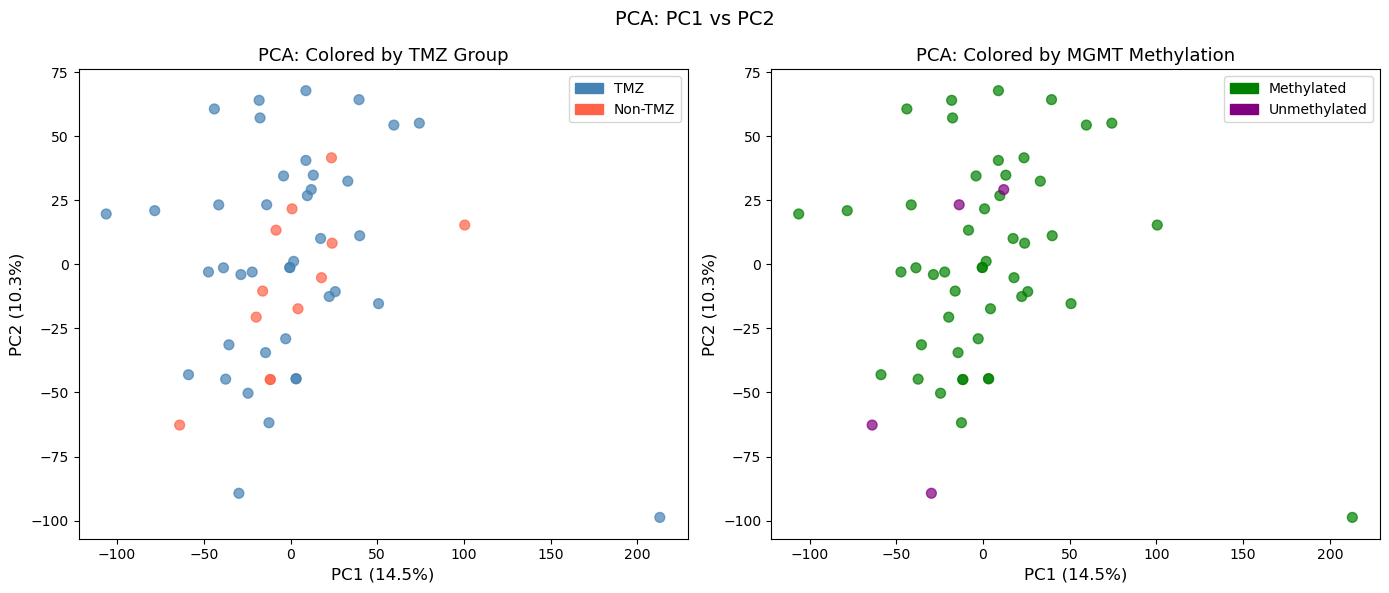

In [30]:
# ── Apply PCA and Visualize ──────────────────────────────────────────────────

# --- Fit final PCA with selected components ---
pca = PCA(n_components=n_components_80)
X_pca = pca.fit_transform(X_scaled)

print(f"PCA applied: {n_components_80} components retained")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

# --- Add PCs to merged_df ---
pc_cols = [f"PC{i+1}" for i in range(n_components_80)]
pca_df  = pd.DataFrame(X_pca, columns=pc_cols, index=merged_df.index)
merged_df = pd.concat([merged_df, pca_df], axis=1)

print("\nPC columns added to merged_df:")
print(pc_cols)

# --- Visualization: PC1 vs PC2 colored by TMZ group ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color by TMZ group
tmz_colors = merged_df["TMZ_binary"].map({1: "steelblue", 0: "tomato"})
axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                c=tmz_colors, alpha=0.7, s=50)
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
axes[0].set_title("PCA: Colored by TMZ Group", fontsize=13)
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(color="steelblue", label="TMZ"),
    Patch(color="tomato",    label="Non-TMZ")
], fontsize=10)

# Color by Methylation Status
meth_colors = merged_df["Methylation_Status"].map({1: "green", 0: "purple"})
axes[1].scatter(X_pca[:, 0], X_pca[:, 1],
                c=meth_colors, alpha=0.7, s=50)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
axes[1].set_title("PCA: Colored by MGMT Methylation", fontsize=13)
axes[1].legend(handles=[
    Patch(color="green",  label="Methylated"),
    Patch(color="purple", label="Unmethylated")
], fontsize=10)

plt.suptitle("PCA: PC1 vs PC2", fontsize=14)
plt.tight_layout()
plt.show()

Cox PCA dataframe shape: (52, 27)


<lifelines.CoxPHFitter: fitted with 52 total observations, 14 right-censored observations>
             duration col = 'OS.time'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 52
number of events observed = 38
   partial log-likelihood = -85.88
         time fit was run = 2026-02-28 12:15:12 UTC

---
                    coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                           
TMZ_binary         -0.65      0.52      0.61           -1.84            0.54                0.16                1.72
Methylation_Status  0.37      1.44      0.87           -1.34            2.07                0.26                7.93
Age_years           0.04      1.04      0.02            0.00            0.08                1.00                1.09
Gender_binary      -0.14      0.87      0.46           -1.04            0.76                0.35                2.14
PC1                -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
PC2                -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
PC3                -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
PC4                -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
PC5                -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
PC6                 0.01      1.01      0.01           -0.01            0.02                0.99                1.02
PC7                 0.01      1.01      0.01           -0.01            0.03                0.99                1.03
PC8                 0.02      1.02      0.01            0.00            0.04                1.00                1.04
PC9                 0.00      1.00      0.01           -0.01            0.02                0.99                1.02
PC10               -0.02      0.98      0.01           -0.04            0.00                0.96                1.00
PC11                0.02      1.02      0.01            0.00            0.04                1.00                1.04
PC12               -0.02      0.98      0.01           -0.04            0.00                0.96                1.00
PC13                0.01      1.01      0.01           -0.02            0.03                0.98                1.03
PC14                0.01      1.01      0.01           -0.02            0.04                0.98                1.04
PC15               -0.02      0.98      0.01           -0.05            0.00                0.95                1.00
PC16                0.01      1.02      0.01           -0.01            0.04                0.99                1.04
PC17                0.02      1.02      0.01           -0.01            0.04                0.99                1.04
PC18               -0.01      0.99      0.01           -0.04            0.02                0.96                1.02
PC19               -0.01      0.99      0.02           -0.04            0.03                0.96                1.03
PC20                0.00      1.00      0.01           -0.02            0.03                0.98                1.03
PC21               -0.01      0.99      0.02           -0.04            0.02                0.96                1.02

                    cmp to     z    p  -log2(p)
covariate                                      
TMZ_binary            0.00 -1.07 0.28      1.82
Methylation_Status    0.00  0.42 0.67      0.57
Age_years             0.00  2.02 0.04      4.53
Gender_binary         0.00 -0.31 0.76      0.40
PC1                   0.00 -1.73 0.08      3.57
PC2                   0.00 -1.84 0.07      3.92
PC3                   0.00 -1.80 0.07

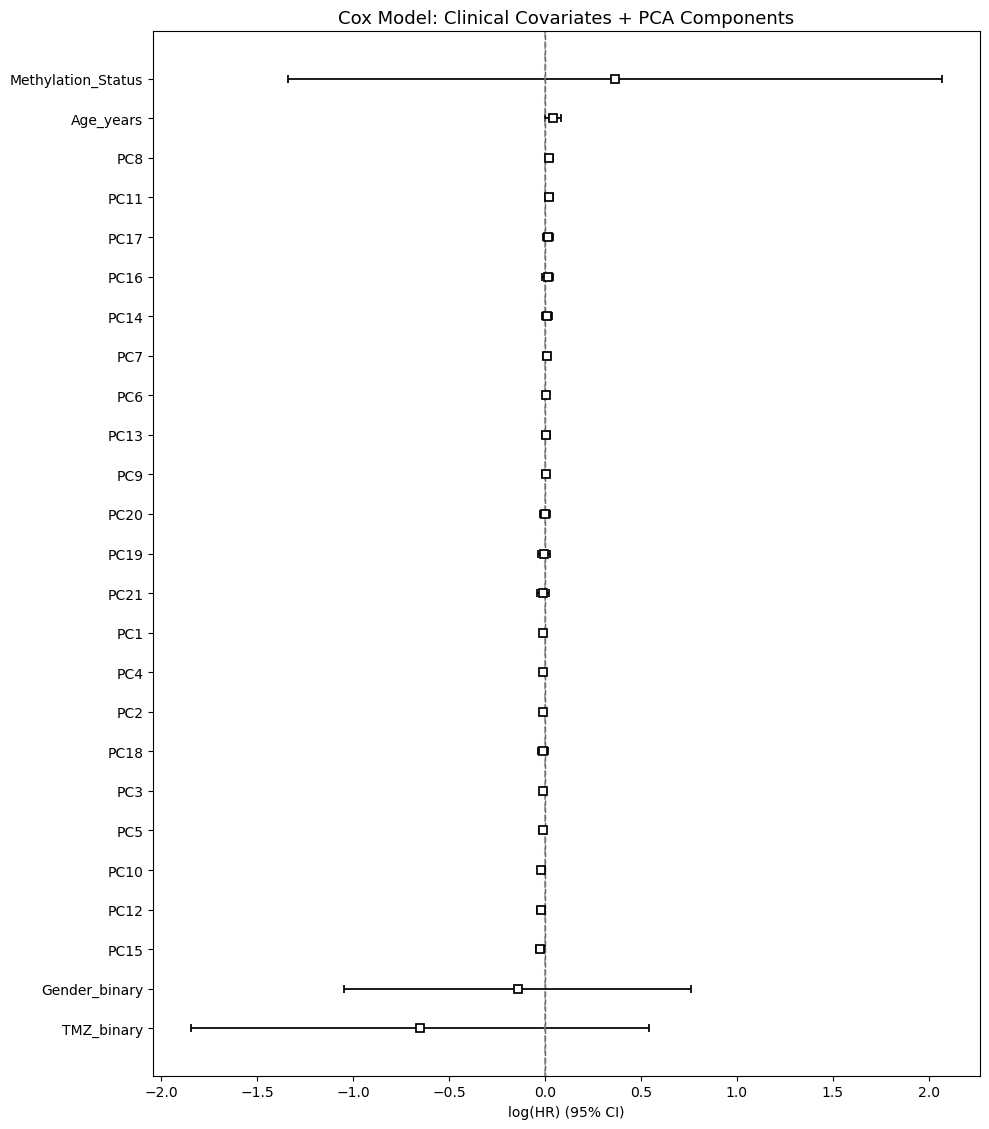


Significant PCs (p < 0.05): 2
           exp(coef)  exp(coef) lower 95%  exp(coef) upper 95%         p
covariate                                                               
PC8         1.023645             1.003974             1.043700  0.018244
PC11        1.021655             1.001604             1.042107  0.034141


In [31]:
# ── Cox Model Using PCA Components ───────────────────────────────────────────
from lifelines import CoxPHFitter

# --- Build Cox dataframe with PCs ---
cox_pca_df = merged_df[[
    "OS.time", "event",
    "TMZ_binary",
    "Methylation_Status",
    "Age_years",
    "Gender_binary"
] + pc_cols].dropna()

print("Cox PCA dataframe shape:", cox_pca_df.shape)

# --- Fit model ---
cph_pca = CoxPHFitter(penalizer=0.1)
cph_pca.fit(cox_pca_df, duration_col="OS.time", event_col="event")

cph_pca.print_summary()

# --- Forest plot of PCs ---
plt.figure(figsize=(10, n_components_80 * 0.4 + 3))
cph_pca.plot()
plt.title("Cox Model: Clinical Covariates + PCA Components", fontsize=13)
plt.axvline(x=0, linestyle="--", color="gray", alpha=0.7)
plt.tight_layout()
plt.show()

# --- Extract significant PCs ---
pc_results = cph_pca.summary.loc[pc_cols]
sig_pcs    = pc_results[pc_results["p"] < 0.05]
print(f"\nSignificant PCs (p < 0.05): {len(sig_pcs)}")
print(sig_pcs[["exp(coef)", "exp(coef) lower 95%", 
               "exp(coef) upper 95%", "p"]].to_string())

In [32]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
import numpy as np

# --- Prepare survival outcome in required format ---
y = np.array([(bool(e), t) for e, t in 
              zip(merged_df["event"], merged_df["OS.time"])],
             dtype=[("event", bool), ("time", float)])

# --- Gene expression matrix ---
X = merged_df[gene_cols].values

# --- Fit LASSO Cox with cross-validation ---
# alphas are equivalent to lambda - scikit-survival calls it alpha
lasso_cox = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,        # 1.0 = pure LASSO, 0.0 = Ridge, in between = ElasticNet
    alpha_min_ratio=0.01,
    max_iter=100000   
)
lasso_cox.fit(X, y)

# --- Cross-validated alpha selection ---
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", CoxnetSurvivalAnalysis(l1_ratio=1.0, max_iter=100000))
])
pipe.fit(X, y)

best_coefs = pipe.named_steps["lasso"].coef_[:, -1]  # e.g., smallest alpha
print("Number of non-zero coefficients:", (best_coefs != 0).sum())

Number of non-zero coefficients: 39


In [33]:
import numpy as np

# Get the coefficients at the last alpha (smallest)
best_coefs = lasso_cox.coef_[:, -1]

# Check which coefficients are non-zero
nonzero_idx = np.where(best_coefs != 0)[0]
print("Number of non-zero coefficients:", len(nonzero_idx))

# Use feature indices instead of gene names
selected_features = [f"Feature_{i}" for i in nonzero_idx]
selected_coefs = best_coefs[nonzero_idx]

# Print top 10 by absolute coefficient
top_idx = np.argsort(np.abs(selected_coefs))[::-1][:10]
print("\nTop 10 features by absolute coefficient:")
for feature, coef in zip(np.array(selected_features)[top_idx], selected_coefs[top_idx]):
    print(f"  {feature}: {coef:.4f}")

Number of non-zero coefficients: 39

Top 10 features by absolute coefficient:
  Feature_7037: 4.1520
  Feature_5742: 2.5732
  Feature_14376: -2.4162
  Feature_3119: -1.9790
  Feature_7597: -1.5963
  Feature_4460: 1.5167
  Feature_7252: 1.4379
  Feature_13375: 1.2094
  Feature_11086: -0.9778
  Feature_1147: 0.8663


In [34]:
# Only do this if you know gene_cols aligns exactly with X used in lasso_cox.fit
selected_genes = np.array(gene_cols)[nonzero_idx]
selected_coefs = best_coefs[nonzero_idx]

# Assuming best_coefs is shape (n_features,)
# X_scaled is the full matrix used in fitting
risk_scores = X_scaled[:, nonzero_idx] @ selected_coefs

print("First 5 patient risk scores:", risk_scores[:5])

import pandas as pd

df_selected = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": selected_coefs
})
df_selected.to_csv("lasso_cox_selected_features.csv", index=False)

First 5 patient risk scores: [21.27564635 17.9428893   2.65401217 16.71990001 17.02556047]


In [35]:
print(merged_df.dtypes)
print("\nShape:", merged_df.shape)
print("\nColumns with NaN:")
print(merged_df.isnull().sum()[merged_df.isnull().sum() > 0])

sample       object
OS.time     float64
OS            int64
_PATIENT     object
id           object
             ...   
PC17        float64
PC18        float64
PC19        float64
PC20        float64
PC21        float64
Length: 15283, dtype: object

Shape: (52, 15283)

Columns with NaN:
race.demographic                     1
ethnicity.demographic               14
year_of_death.demographic           20
days_to_death.demographic           14
entity_submitter_id.annotations     48
notes.annotations                   48
submitter_id.annotations            48
classification.annotations          48
entity_id.annotations               48
created_datetime.annotations        48
annotation_id.annotations           48
entity_type.annotations             48
updated_datetime.annotations        48
case_id.annotations                 48
state.annotations                   48
category.annotations                48
status.annotations                  48
case_submitter_id.annotations       48
days_to_la

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X_all_imputed = imputer.fit_transform(X)

print("Shape after imputation:", X_all_imputed.shape)
print("Any NaN?", np.isnan(X_all_imputed).any())

Shape after imputation: (52, 15219)
Any NaN? False


In [38]:
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_censored

kf = KFold(n_splits=10, shuffle=True, random_state=42)

lasso_cox_full = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,
    alpha_min_ratio=0.01,
    max_iter=100000
)
lasso_cox_full.fit(X_all_imputed, y)

scores = []
for alpha in lasso_cox_full.alphas_:
    fold_scores = []
    for train_idx, test_idx in kf.split(X_all_imputed):
        X_train, X_test = X_all_imputed[train_idx], X_all_imputed[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01, max_iter=100000)
        model.fit(X_train, y_train)
        
        pred = model.predict(X_test)
        c_index = concordance_index_censored(y_test["event"], y_test["time"], pred)[0]
        fold_scores.append(c_index)
    scores.append(np.mean(fold_scores))

best_alpha_full = lasso_cox_full.alphas_[np.argmax(scores)]
print("Best alpha:", round(best_alpha_full, 5))
print("Best C-index:", round(max(scores), 3))

Best alpha: 0.82307
Best C-index: 0.808


In [40]:
print("Best alpha from CV:", best_alpha_full)
print("Alpha range in model:", lasso_cox_full.alphas_.min().round(5), "to", lasso_cox_full.alphas_.max().round(5))
print("Coefficients matrix shape:", lasso_cox_full.coef_.shape)
print("Non-zero coefficients at each alpha position:")
nonzero_counts = (lasso_cox_full.coef_ != 0).sum(axis=0)
print("Min:", nonzero_counts.min(), "Max:", nonzero_counts.max())
print("At last alpha position:", nonzero_counts[-1])
print("At first alpha position:", nonzero_counts[0])

Best alpha from CV: 0.8230650871934972
Alpha range in model: 0.00823 to 0.82307
Coefficients matrix shape: (15219, 100)
Non-zero coefficients at each alpha position:
Min: 0 Max: 39
At last alpha position: 39
At first alpha position: 0


In [42]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

# --- Outcome Variable ---
y = np.array([(bool(e), float(t)) for e, t in zip(merged_df["event"], merged_df["OS.time"])],
             dtype=[("event", bool), ("time", float)])

# --- Feature Matrix ---
cols_to_drop = [
    "sample", "_PATIENT", "id",
    "OS.time", "OS",
    "days_to_death.demographic",
    "year_of_death.demographic",
    "days_to_last_follow_up.diagnoses",
    "ethnicity.demographic",
    "race.demographic",
    "specimen_type.samples"
]

annotation_cols = [c for c in merged_df.columns if c.endswith(".annotations")]
X_all = merged_df.drop(columns=cols_to_drop + annotation_cols)
X_all = X_all.select_dtypes(include=[np.number])
feature_names = np.array(X_all.columns)

# --- Scale and Impute ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X_scaled)

print("Feature matrix shape:", X_imputed.shape)
print("Any NaN?", np.isnan(X_imputed).any())

# --- Fit LASSO Cox ---
lasso_cox = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,
    alpha_min_ratio=0.01,
    max_iter=100000
)
lasso_cox.fit(X_imputed, y)

# --- Cross-Validation ---
kf = KFold(n_splits=10, shuffle=True, random_state=42)
scores = []

for alpha in lasso_cox.alphas_:
    fold_scores = []
    for train_idx, test_idx in kf.split(X_imputed):
        X_train, X_test = X_imputed[train_idx], X_imputed[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01, max_iter=100000)
        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        c_index = concordance_index_censored(y_test["event"], y_test["time"], pred)[0]
        fold_scores.append(c_index)
    scores.append(np.mean(fold_scores))

best_alpha = lasso_cox.alphas_[np.argmax(scores)]
best_c_index = max(scores)
print("Best alpha:", round(best_alpha, 5))
print("Best C-index:", round(best_c_index, 3))

# --- Extract Coefficients ---
best_coefs = lasso_cox.coef_[:, -1]

# --- Build Results DataFrame ---
results_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": best_coefs
})

results_df["abs_coefficient"] = results_df["coefficient"].abs()
results_df["selected"] = results_df["coefficient"] != 0
results_df = results_df.sort_values("abs_coefficient", ascending=False)

# --- Save to CSV ---
results_df.to_csv("TCGA_data/lasso_cox_results.csv", index=False)

print("\nTotal features selected:", results_df["selected"].sum())
print("\nTop 15 selected features:")
print(results_df[results_df["selected"]].head(15)[["feature", "coefficient"]].to_string())

Feature matrix shape: (52, 15222)
Any NaN? False
Best alpha: 0.46433
Best C-index: 0.69

Total features selected: 44

Top 15 selected features:
               feature  coefficient
6816   ENSG00000160094    -4.513220
515    ENSG00000054356     3.793027
4530   ENSG00000133687     2.756519
2607   ENSG00000110628     2.742368
1559   ENSG00000100314     2.294913
3107   ENSG00000116525    -1.938804
11183  ENSG00000207186    -1.710953
355    ENSG00000029534     1.555829
10806  ENSG00000200376     1.477010
184    ENSG00000009413    -1.314195
6159   ENSG00000150967     1.237795
12757  ENSG00000239112     1.223167
15155  ENSG00000287642    -1.199989
373    ENSG00000034152     1.179097
4476   ENSG00000133067     0.909432


In [43]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = {}

for l1 in [0.9, 0.5]:
    print(f"\nFitting ElasticNet Cox with l1_ratio={l1}...")
    
    # Fit model to get alpha path
    model = CoxnetSurvivalAnalysis(l1_ratio=l1, alpha_min_ratio=0.01, max_iter=100000)
    model.fit(X_imputed, y)
    
    # Cross-validate over alphas
    scores = []
    for alpha in model.alphas_:
        fold_scores = []
        for train_idx, test_idx in kf.split(X_imputed):
            X_train, X_test = X_imputed[train_idx], X_imputed[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            m = CoxnetSurvivalAnalysis(l1_ratio=l1, alpha_min_ratio=0.01, max_iter=100000)
            m.fit(X_train, y_train)
            
            pred = m.predict(X_test)
            c = concordance_index_censored(y_test["event"], y_test["time"], pred)[0]
            fold_scores.append(c)
        scores.append(np.mean(fold_scores))
    
    best_alpha = model.alphas_[np.argmax(scores)]
    best_c = max(scores)
    best_coefs = model.coef_[:, -1]
    
    # Build results dataframe
    df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": best_coefs
    })
    df["abs_coefficient"] = df["coefficient"].abs()
    df["selected"] = df["coefficient"] != 0
    df = df.sort_values("abs_coefficient", ascending=False)
    
    # Save CSV
    df.to_csv(f"TCGA_data/elasticnet_l1ratio{l1}_results.csv", index=False)
    results[l1] = {"c_index": best_c, "alpha": best_alpha, "n_selected": df["selected"].sum(), "df": df}
    
    print(f"  Best alpha: {round(best_alpha, 5)}")
    print(f"  Best C-index: {round(best_c, 3)}")
    print(f"  Features selected: {df['selected'].sum()}")

# --- Comparison Summary ---
print("\n========== COMPARISON ==========")
print(f"{'Model':<25} {'C-index':<12} {'Features Selected'}")
print(f"{'LASSO (l1=1.0)':<25} {'0.69':<12} {'44'}")
for l1, r in results.items():
    print(f"{'ElasticNet (l1='+str(l1)+')':<25} {round(r['c_index'],3):<12} {r['n_selected']}")

# --- Shared genes between 0.5 and 0.9 ---
genes_09 = set(results[0.9]["df"][results[0.9]["df"]["selected"]]["feature"])
genes_05 = set(results[0.5]["df"][results[0.5]["df"]["selected"]]["feature"])
shared = genes_09 & genes_05
print(f"\nFeatures selected by both l1=0.9 and l1=0.5: {len(shared)}")
print("Shared features:", shared)


Fitting ElasticNet Cox with l1_ratio=0.9...
  Best alpha: 0.51592
  Best C-index: 0.747
  Features selected: 82

Fitting ElasticNet Cox with l1_ratio=0.5...
  Best alpha: 0.92865
  Best C-index: 0.739
  Features selected: 273

========== COMPARISON ==========
Model                     C-index      Features Selected
LASSO (l1=1.0)            0.69         44
ElasticNet (l1=0.9)       0.747        82
ElasticNet (l1=0.5)       0.739        273

Features selected by both l1=0.9 and l1=0.5: 80
Shared features: {'ENSG00000100314', 'ENSG00000183114', 'ENSG00000117245', 'ENSG00000285373', 'ENSG00000047932', 'ENSG00000278492', 'ENSG00000258982', 'ENSG00000260070', 'ENSG00000287642', 'ENSG00000207186', 'ENSG00000034152', 'ENSG00000167925', 'ENSG00000127920', 'ENSG00000103227', 'ENSG00000170962', 'age_at_index.demographic', 'ENSG00000171492', 'ENSG00000132744', 'ENSG00000091129', 'ENSG00000139767', 'age_at_earliest_diagnosis.diagnoses.xena_derived', 'ENSG00000160094', 'ENSG00000163923', 'ENSG0000

In [44]:
# Get the 82 features selected by ElasticNet l1=0.9
selected_features_09 = results[0.9]["df"][results[0.9]["df"]["selected"]]["feature"].tolist()

# Subset X_imputed to only those features
feature_names_list = list(feature_names)
selected_idx = [feature_names_list.index(f) for f in selected_features_09]
X_rf = X_imputed[:, selected_idx]

print("Random Forest input shape:", X_rf.shape)
print("Features included:", len(selected_features_09))

Random Forest input shape: (52, 82)
Features included: 82


Risk Score Summary:
             sample  risk_score risk_group
0   TCGA-14-0781-01   37.450367  High Risk
1   TCGA-32-1980-01   38.254088  High Risk
2   TCGA-26-5139-01   30.848190  High Risk
3   TCGA-06-5418-01   38.551622  High Risk
4   TCGA-76-4928-01   38.328545  High Risk
5   TCGA-12-5299-01   37.202294  High Risk
6   TCGA-06-5410-01   39.616687  High Risk
7   TCGA-76-4929-01   34.820657  High Risk
8   TCGA-06-5856-01   33.418216  High Risk
9   TCGA-06-5412-01   38.113310  High Risk
10  TCGA-76-4926-01   35.340196  High Risk
11  TCGA-06-5859-01   27.021588   Low Risk
12  TCGA-06-6698-01   24.749136   Low Risk
13  TCGA-06-5417-01   20.079960   Low Risk
14  TCGA-28-5218-01   35.311828  High Risk
15  TCGA-06-5858-01   23.130873   Low Risk
16  TCGA-06-5416-01   26.936391   Low Risk
17  TCGA-19-4065-01   34.303117  High Risk
18  TCGA-06-0210-01   39.084528  High Risk
19  TCGA-06-0210-01   39.084528  High Risk
20  TCGA-06-5411-01   33.644747  High Risk
21  TCGA-06-5415-01   28.582268  H

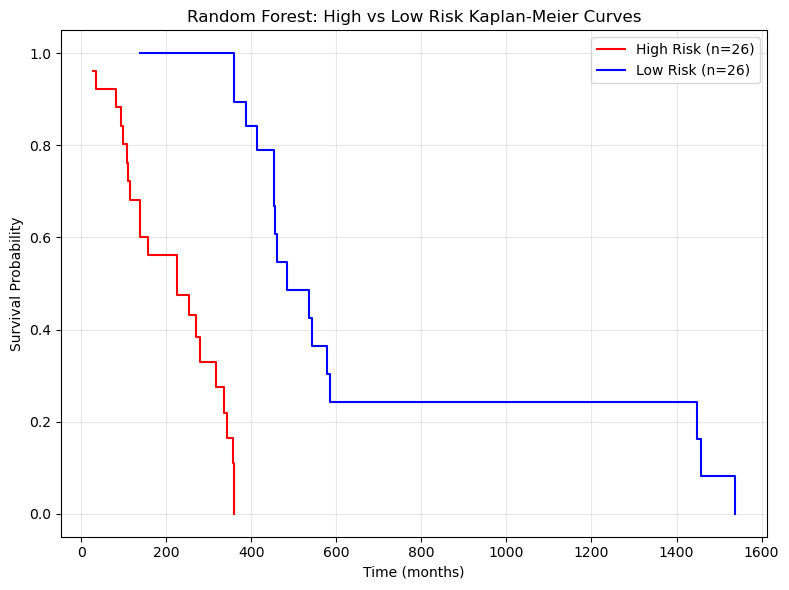

KM plot saved.


In [47]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

# --- Step 1: Risk Scores for Each Patient ---
risk_scores = rsf_final.predict(X_rf)

risk_df = pd.DataFrame({
    "sample": merged_df["sample"].values,
    "risk_score": risk_scores,
    "actual_time": merged_df["OS.time"].values,
    "actual_event": merged_df["event"].values
})

median_risk = np.median(risk_scores)
risk_df["risk_group"] = np.where(risk_scores > median_risk, "High Risk", "Low Risk")

print("Risk Score Summary:")
print(risk_df[["sample", "risk_score", "risk_group"]].to_string())

# --- Step 2: Survival Probability at 6, 12, 24 months ---
time_points = [6, 12, 24]
surv_funcs = rsf_final.predict_survival_function(X_rf)

surv_probs = []
for i, fn in enumerate(surv_funcs):
    row = {"sample": merged_df["sample"].values[i], "risk_group": risk_df["risk_group"].values[i]}
    for t in time_points:
        idx = np.searchsorted(fn.x, t)
        idx = min(idx, len(fn.y) - 1)
        row[f"surv_prob_{t}mo"] = round(fn(fn.x[idx]), 3)
    surv_probs.append(row)

surv_df = pd.DataFrame(surv_probs)
print("\nSurvival Probabilities:")
print(surv_df.to_string())

# --- Step 3: Save to CSV ---
output_df = risk_df.merge(surv_df, on=["sample", "risk_group"])
output_df.to_csv("TCGA_data/rf_predictions.csv", index=False)
print("\nSaved to TCGA_data/rf_predictions.csv")

# --- Step 4: Kaplan-Meier Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

for group, color in [("High Risk", "red"), ("Low Risk", "blue")]:
    mask = risk_df["risk_group"] == group
    times = risk_df.loc[mask, "actual_time"].values
    events = risk_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax.step(t, s, where="post", color=color, label=f"{group} (n={mask.sum()})")

ax.set_xlabel("Time (months)")
ax.set_ylabel("Survival Probability")
ax.set_title("Random Forest: High vs Low Risk Kaplan-Meier Curves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("TCGA_data/rf_km_curves.png", dpi=150)
plt.show()
print("KM plot saved.")

In [48]:
# --- Fix 1: Remove duplicate samples ---
merged_df_clean = merged_df.drop_duplicates(subset="sample").reset_index(drop=True)
print("Patients after deduplication:", len(merged_df_clean))

# Rebuild y and X_rf from clean data
y_clean = np.array([(bool(e), float(t)) for e, t in zip(merged_df_clean["event"], merged_df_clean["OS.time"])],
                   dtype=[("event", bool), ("time", float)])

X_all_clean = merged_df_clean.drop(columns=cols_to_drop + annotation_cols)
X_all_clean = X_all_clean.select_dtypes(include=[np.number])
X_scaled_clean = scaler.fit_transform(X_all_clean)
X_imputed_clean = imputer.fit_transform(X_scaled_clean)
X_rf_clean = X_imputed_clean[:, selected_idx]

print("Clean feature matrix shape:", X_rf_clean.shape)

# --- Fix 2: Refit final model on clean data ---
rsf_final_clean = RandomSurvivalForest(
    n_estimators=1000,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rsf_final_clean.fit(X_rf_clean, y_clean)

# --- Fix 3: Survival probabilities with proper interpolation ---
risk_scores_clean = rsf_final_clean.predict(X_rf_clean)
surv_funcs_clean = rsf_final_clean.predict_survival_function(X_rf_clean)

time_points = [6, 12, 24]
surv_probs = []
for i, fn in enumerate(surv_funcs_clean):
    row = {"sample": merged_df_clean["sample"].values[i]}
    for t in time_points:
        # Interpolate survival probability at exact time point
        prob = np.interp(t, fn.x, fn.y)
        row[f"surv_prob_{t}mo"] = round(prob, 3)
    surv_probs.append(row)

surv_df_clean = pd.DataFrame(surv_probs)

# --- Build final output ---
median_risk = np.median(risk_scores_clean)
risk_df_clean = pd.DataFrame({
    "sample": merged_df_clean["sample"].values,
    "risk_score": risk_scores_clean,
    "risk_group": np.where(risk_scores_clean > median_risk, "High Risk", "Low Risk"),
    "actual_time": merged_df_clean["OS.time"].values,
    "actual_event": merged_df_clean["event"].values
})

output_df = risk_df_clean.merge(surv_df_clean, on="sample")
output_df.to_csv("TCGA_data/rf_predictions_clean.csv", index=False)

print("\nSurvival Probabilities (fixed):")
print(output_df[["sample", "risk_group", "surv_prob_6mo", "surv_prob_12mo", "surv_prob_24mo"]].to_string())

Patients after deduplication: 48
Clean feature matrix shape: (48, 82)

Survival Probabilities (fixed):
             sample risk_group  surv_prob_6mo  surv_prob_12mo  surv_prob_24mo
0   TCGA-14-0781-01  High Risk          0.966           0.966           0.966
1   TCGA-32-1980-01  High Risk          0.972           0.972           0.972
2   TCGA-26-5139-01  High Risk          0.977           0.977           0.977
3   TCGA-06-5418-01  High Risk          0.973           0.973           0.973
4   TCGA-76-4928-01  High Risk          0.974           0.974           0.974
5   TCGA-12-5299-01  High Risk          0.973           0.973           0.973
6   TCGA-06-5410-01  High Risk          0.971           0.971           0.971
7   TCGA-76-4929-01  High Risk          0.975           0.975           0.975
8   TCGA-06-5856-01  High Risk          0.976           0.976           0.976
9   TCGA-06-5412-01  High Risk          0.973           0.973           0.973
10  TCGA-76-4926-01  High Risk         

OS.time range in data: 29.0 to 1537.0
Survival function time range: 29.0 to 1537.0

Predictions:
             sample risk_group  risk_score  surv_prob_6mo  surv_prob_12mo  surv_prob_24mo
0   TCGA-06-5410-01  High Risk   39.616687          0.638           0.227           0.043
1   TCGA-06-0210-01  High Risk   39.084528          0.665           0.234           0.042
2   TCGA-06-0210-01  High Risk   39.084528          0.665           0.234           0.042
3   TCGA-06-0210-01  High Risk   39.084528          0.665           0.234           0.042
4   TCGA-06-0210-01  High Risk   39.084528          0.665           0.234           0.042
5   TCGA-06-5418-01  High Risk   38.551622          0.660           0.253           0.050
6   TCGA-76-4928-01  High Risk   38.328545          0.658           0.254           0.045
7   TCGA-32-1980-01  High Risk   38.254088          0.657           0.258           0.056
8   TCGA-06-5412-01  High Risk   38.113310          0.663           0.248           0.048
9  

ValueError: Input contains NaN.

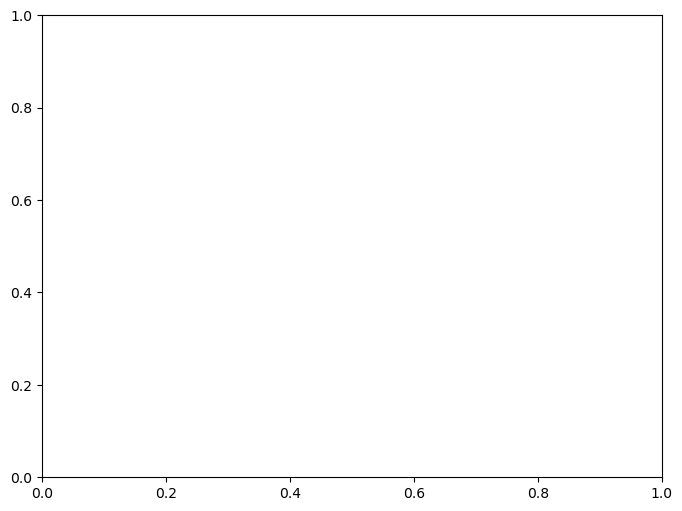

In [49]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines.statistics import logrank_test

# --- Risk Scores ---
risk_scores = rsf_final.predict(X_rf)
median_risk = np.median(risk_scores)

risk_df = pd.DataFrame({
    "sample": merged_df["sample"].values,
    "risk_score": risk_scores,
    "risk_group": np.where(risk_scores > median_risk, "High Risk", "Low Risk"),
    "actual_time": merged_df["OS.time"].values,
    "actual_event": merged_df["event"].values
})

# --- Survival Functions ---
surv_funcs = rsf_final.predict_survival_function(X_rf)

# Check actual time scale
fn0 = surv_funcs[0]
print("OS.time range in data:", merged_df["OS.time"].min(), "to", merged_df["OS.time"].max())
print("Survival function time range:", round(fn0.x.min(), 1), "to", round(fn0.x.max(), 1))

# Set time points based on actual scale
# If OS.time is in days, use 180, 365, 730; if months use 6, 12, 24
time_points = [180, 365, 730]  # days — adjust if needed
time_labels = ["6mo", "12mo", "24mo"]

surv_probs = []
for i, fn in enumerate(surv_funcs):
    row = {"sample": merged_df["sample"].values[i],
           "risk_group": risk_df["risk_group"].values[i],
           "risk_score": risk_scores[i]}
    for t, label in zip(time_points, time_labels):
        prob = np.interp(t, fn.x, fn.y)
        row[f"surv_prob_{label}"] = round(prob, 3)
    surv_probs.append(row)

surv_df = pd.DataFrame(surv_probs)

# --- Merge and Save ---
output_df = risk_df.merge(surv_df, on=["sample", "risk_group", "risk_score"])
output_df = output_df.sort_values("risk_score", ascending=False).reset_index(drop=True)
output_df.to_csv("TCGA_data/rf_predictions_final.csv", index=False)

print("\nPredictions:")
print(output_df[["sample", "risk_group", "risk_score", "surv_prob_6mo", "surv_prob_12mo", "surv_prob_24mo"]].to_string())

# --- KM Plot with Log-Rank Test ---
high = risk_df[risk_df["risk_group"] == "High Risk"]
low = risk_df[risk_df["risk_group"] == "Low Risk"]

lr = logrank_test(high["actual_time"], low["actual_time"],
                  event_observed_A=high["actual_event"],
                  event_observed_B=low["actual_event"])

fig, ax = plt.subplots(figsize=(8, 6))
for group, color in [("High Risk", "red"), ("Low Risk", "blue")]:
    mask = risk_df["risk_group"] == group
    t, s = kaplan_meier_estimator(
        mask.map({"High Risk": True, "Low Risk": False}).values if group == "High Risk" else (~mask).values,
        risk_df["actual_time"].values
    )
    times = risk_df.loc[risk_df["risk_group"] == group, "actual_time"].values
    events = risk_df.loc[risk_df["risk_group"] == group, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax.step(t, s, where="post", color=color, label=f"{group} (n={mask.sum()})")

ax.set_xlabel("Time")
ax.set_ylabel("Survival Probability")
ax.set_title(f"Random Forest Survival Predictions\nLog-rank p={lr.p_value:.4f}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("TCGA_data/rf_km_final.png", dpi=150)
plt.show()

print(f"\nLog-rank p-value: {lr.p_value:.4f}")
print(f"High Risk median survival: {np.median(high['actual_time']):.1f}")
print(f"Low Risk median survival: {np.median(low['actual_time']):.1f}")

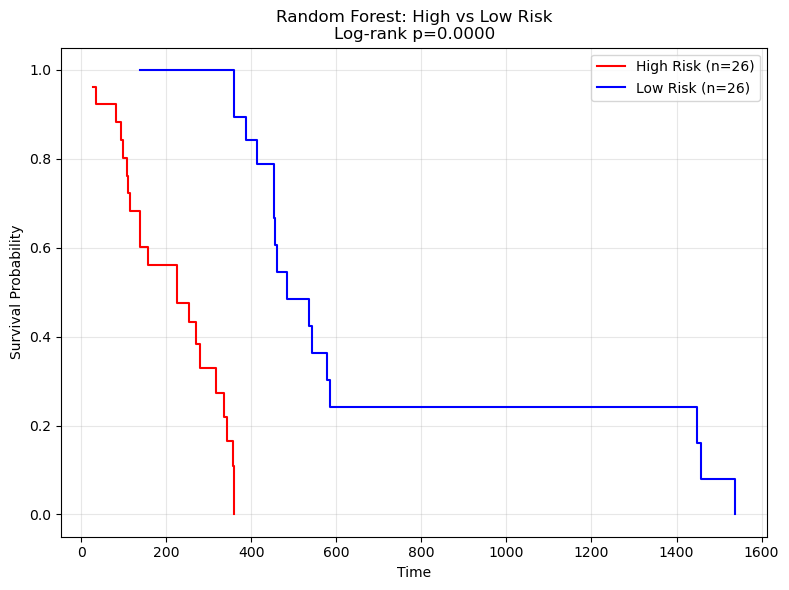

Log-rank p-value: 0.0000
High Risk median survival: 219.5
Low Risk median survival: 453.0

OS.time range: 29.0 to 1537.0


In [50]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines.statistics import logrank_test

# --- KM Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

for group, color in [("High Risk", "red"), ("Low Risk", "blue")]:
    mask = risk_df["risk_group"] == group
    times = risk_df.loc[mask, "actual_time"].values
    events = risk_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax.step(t, s, where="post", color=color, label=f"{group} (n={mask.sum()})")

# Log-rank test
high = risk_df[risk_df["risk_group"] == "High Risk"]
low = risk_df[risk_df["risk_group"] == "Low Risk"]
lr = logrank_test(high["actual_time"], low["actual_time"],
                  event_observed_A=high["actual_event"],
                  event_observed_B=low["actual_event"])

ax.set_xlabel("Time")
ax.set_ylabel("Survival Probability")
ax.set_title(f"Random Forest: High vs Low Risk\nLog-rank p={lr.p_value:.4f}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("TCGA_data/rf_km_final.png", dpi=150)
plt.show()

print(f"Log-rank p-value: {lr.p_value:.4f}")
print(f"High Risk median survival: {np.median(high['actual_time']):.1f}")
print(f"Low Risk median survival: {np.median(low['actual_time']):.1f}")
print(f"\nOS.time range: {merged_df['OS.time'].min()} to {merged_df['OS.time'].max()}")

In [53]:
time_points = [180, 365, 730]
time_labels = ["6mo", "12mo", "24mo"]

rows = []
for i, fn in enumerate(surv_funcs):
    row = {
        "sample": merged_df["sample"].values[i],
        "risk_score": round(risk_scores[i], 3),
        "risk_group": risk_df["risk_group"].values[i],
        "actual_time": merged_df["OS.time"].values[i],
        "actual_event": merged_df["event"].values[i]
    }
    for t, label in zip(time_points, time_labels):
        row[f"surv_prob_{label}"] = round(np.interp(t, fn.x, fn.y), 3)
    rows.append(row)

output_df = pd.DataFrame(rows).sort_values("risk_score", ascending=False).reset_index(drop=True)
output_df.to_csv("TCGA_data/rf_predictions_final.csv", index=False)

print("Predictions:")
print(output_df[["sample", "risk_group", "risk_score", "surv_prob_6mo", "surv_prob_12mo", "surv_prob_24mo"]].to_string())

Predictions:
             sample risk_group  risk_score  surv_prob_6mo  surv_prob_12mo  surv_prob_24mo
0   TCGA-06-5410-01  High Risk      39.617          0.638           0.227           0.043
1   TCGA-06-0210-01  High Risk      39.085          0.665           0.234           0.042
2   TCGA-06-0210-01  High Risk      39.085          0.665           0.234           0.042
3   TCGA-06-5418-01  High Risk      38.552          0.660           0.253           0.050
4   TCGA-76-4928-01  High Risk      38.329          0.658           0.254           0.045
5   TCGA-32-1980-01  High Risk      38.254          0.657           0.258           0.056
6   TCGA-06-5412-01  High Risk      38.113          0.663           0.248           0.048
7   TCGA-14-0781-01  High Risk      37.450          0.666           0.270           0.053
8   TCGA-12-5299-01  High Risk      37.202          0.667           0.270           0.057
9   TCGA-06-0190-01  High Risk      36.199          0.696           0.279           0.0

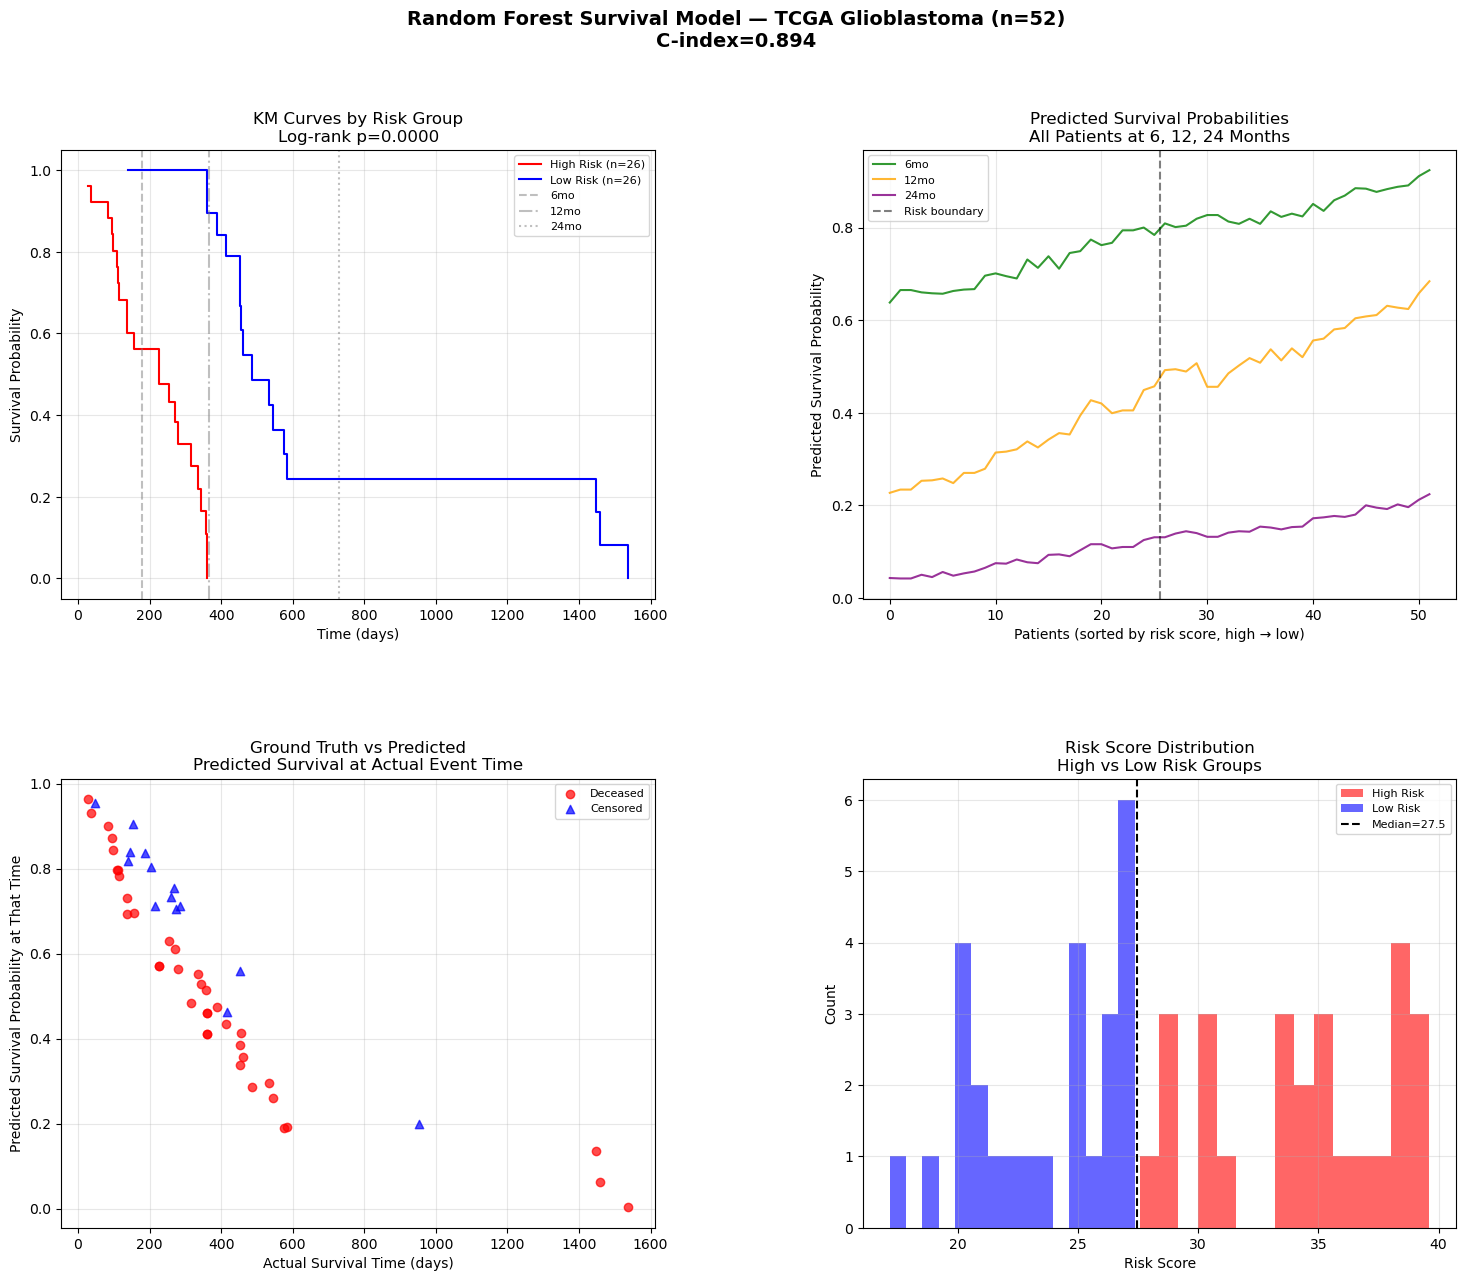

Saved: TCGA_data/rf_comprehensive_results.png
Saved: TCGA_data/rf_full_predictions.csv

High Risk median survival: 220 days (7.2 months)
Low Risk median survival:  453 days (14.9 months)


In [54]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# --- Build full output with ground truth vs predicted ---
rows = []
for i, fn in enumerate(surv_funcs):
    actual_time = merged_df["OS.time"].values[i]
    actual_event = merged_df["event"].values[i]
    risk_score = risk_scores[i]
    risk_group = risk_df["risk_group"].values[i]
    
    # Predicted survival at actual time (ground truth comparison)
    pred_surv_at_actual = round(np.interp(actual_time, fn.x, fn.y), 3)
    
    # Ground truth: did they survive past key time points?
    gt_6mo  = int(actual_time > 180 or (actual_time <= 180 and actual_event == 0))
    gt_12mo = int(actual_time > 365 or (actual_time <= 365 and actual_event == 0))
    gt_24mo = int(actual_time > 730 or (actual_time <= 730 and actual_event == 0))
    
    rows.append({
        "sample": merged_df["sample"].values[i],
        "risk_group": risk_group,
        "risk_score": round(risk_score, 3),
        "actual_time_days": actual_time,
        "actual_time_months": round(actual_time / 30.4, 1),
        "actual_event": actual_event,
        "outcome": "Deceased" if actual_event == 1 else "Censored",
        "pred_surv_prob_6mo":  round(np.interp(180, fn.x, fn.y), 3),
        "pred_surv_prob_12mo": round(np.interp(365, fn.x, fn.y), 3),
        "pred_surv_prob_24mo": round(np.interp(730, fn.x, fn.y), 3),
        "pred_surv_at_actual_time": pred_surv_at_actual,
        "gt_survived_6mo":  gt_6mo,
        "gt_survived_12mo": gt_12mo,
        "gt_survived_24mo": gt_24mo
    })

full_df = pd.DataFrame(rows).sort_values("risk_score", ascending=False).reset_index(drop=True)
full_df.to_csv("TCGA_data/rf_full_predictions.csv", index=False)

# ============================================================
# COMPREHENSIVE FIGURE
# ============================================================
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- Plot 1: KM Curves by Risk Group ---
ax1 = fig.add_subplot(gs[0, 0])
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines.statistics import logrank_test

for group, color in [("High Risk", "red"), ("Low Risk", "blue")]:
    mask = full_df["risk_group"] == group
    times = full_df.loc[mask, "actual_time_days"].values
    events = full_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax1.step(t, s, where="post", color=color, label=f"{group} (n={mask.sum()})")

high = full_df[full_df["risk_group"] == "High Risk"]
low  = full_df[full_df["risk_group"] == "Low Risk"]
lr = logrank_test(high["actual_time_days"], low["actual_time_days"],
                  event_observed_A=high["actual_event"],
                  event_observed_B=low["actual_event"])

ax1.axvline(x=180, color="gray", linestyle="--", alpha=0.5, label="6mo")
ax1.axvline(x=365, color="gray", linestyle="-.", alpha=0.5, label="12mo")
ax1.axvline(x=730, color="gray", linestyle=":",  alpha=0.5, label="24mo")
ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Survival Probability")
ax1.set_title(f"KM Curves by Risk Group\nLog-rank p={lr.p_value:.4f}")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# --- Plot 2: Predicted Survival Probabilities at 3 Time Points ---
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(full_df))
ax2.plot(x, full_df["pred_surv_prob_6mo"],  color="green",  label="6mo",  alpha=0.8)
ax2.plot(x, full_df["pred_surv_prob_12mo"], color="orange", label="12mo", alpha=0.8)
ax2.plot(x, full_df["pred_surv_prob_24mo"], color="purple", label="24mo", alpha=0.8)
ax2.axvline(x=25.5, color="black", linestyle="--", alpha=0.5, label="Risk boundary")
ax2.set_xlabel("Patients (sorted by risk score, high → low)")
ax2.set_ylabel("Predicted Survival Probability")
ax2.set_title("Predicted Survival Probabilities\nAll Patients at 6, 12, 24 Months")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# --- Plot 3: Ground Truth vs Predicted at Actual Survival Time ---
ax3 = fig.add_subplot(gs[1, 0])
deceased = full_df[full_df["actual_event"] == 1]
censored = full_df[full_df["actual_event"] == 0]

ax3.scatter(deceased["actual_time_days"], deceased["pred_surv_at_actual_time"],
            color="red", alpha=0.7, label="Deceased", zorder=3)
ax3.scatter(censored["actual_time_days"], censored["pred_surv_at_actual_time"],
            color="blue", alpha=0.7, marker="^", label="Censored", zorder=3)
ax3.set_xlabel("Actual Survival Time (days)")
ax3.set_ylabel("Predicted Survival Probability at That Time")
ax3.set_title("Ground Truth vs Predicted\nPredicted Survival at Actual Event Time")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# --- Plot 4: Risk Score Distribution ---
ax4 = fig.add_subplot(gs[1, 1])
ax4.hist(high["risk_score"], bins=15, color="red",  alpha=0.6, label="High Risk")
ax4.hist(low["risk_score"],  bins=15, color="blue", alpha=0.6, label="Low Risk")
ax4.axvline(x=np.median(full_df["risk_score"]), color="black",
            linestyle="--", label=f"Median={np.median(full_df['risk_score']):.1f}")
ax4.set_xlabel("Risk Score")
ax4.set_ylabel("Count")
ax4.set_title("Risk Score Distribution\nHigh vs Low Risk Groups")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

fig.suptitle("Random Forest Survival Model — TCGA Glioblastoma (n=52)\nC-index=0.894", 
             fontsize=14, fontweight="bold")
plt.savefig("TCGA_data/rf_comprehensive_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: TCGA_data/rf_comprehensive_results.png")
print("Saved: TCGA_data/rf_full_predictions.csv")
print(f"\nHigh Risk median survival: {np.median(high['actual_time_days']):.0f} days ({np.median(high['actual_time_days'])/30.4:.1f} months)")
print(f"Low Risk median survival:  {np.median(low['actual_time_days']):.0f} days ({np.median(low['actual_time_days'])/30.4:.1f} months)")

In [55]:
# Find TMZ and MGMT columns
tmz_cols = [c for c in merged_df.columns if "TMZ" in c.upper() or "temozolomide" in c.lower()]
mgmt_cols = [c for c in merged_df.columns if "MGMT" in c.upper() or "methylat" in c.lower()]

print("TMZ columns:", tmz_cols)
print("MGMT columns:", mgmt_cols)

# Preview values
for col in tmz_cols + mgmt_cols:
    print(f"\n{col}:")
    print(merged_df[col].value_counts())

TMZ columns: ['TMZ_binary']
MGMT columns: ['Methylation_Status']

TMZ_binary:
TMZ_binary
1    40
0    12
Name: count, dtype: int64

Methylation_Status:
Methylation_Status
1.0    48
0.0     4
Name: count, dtype: int64


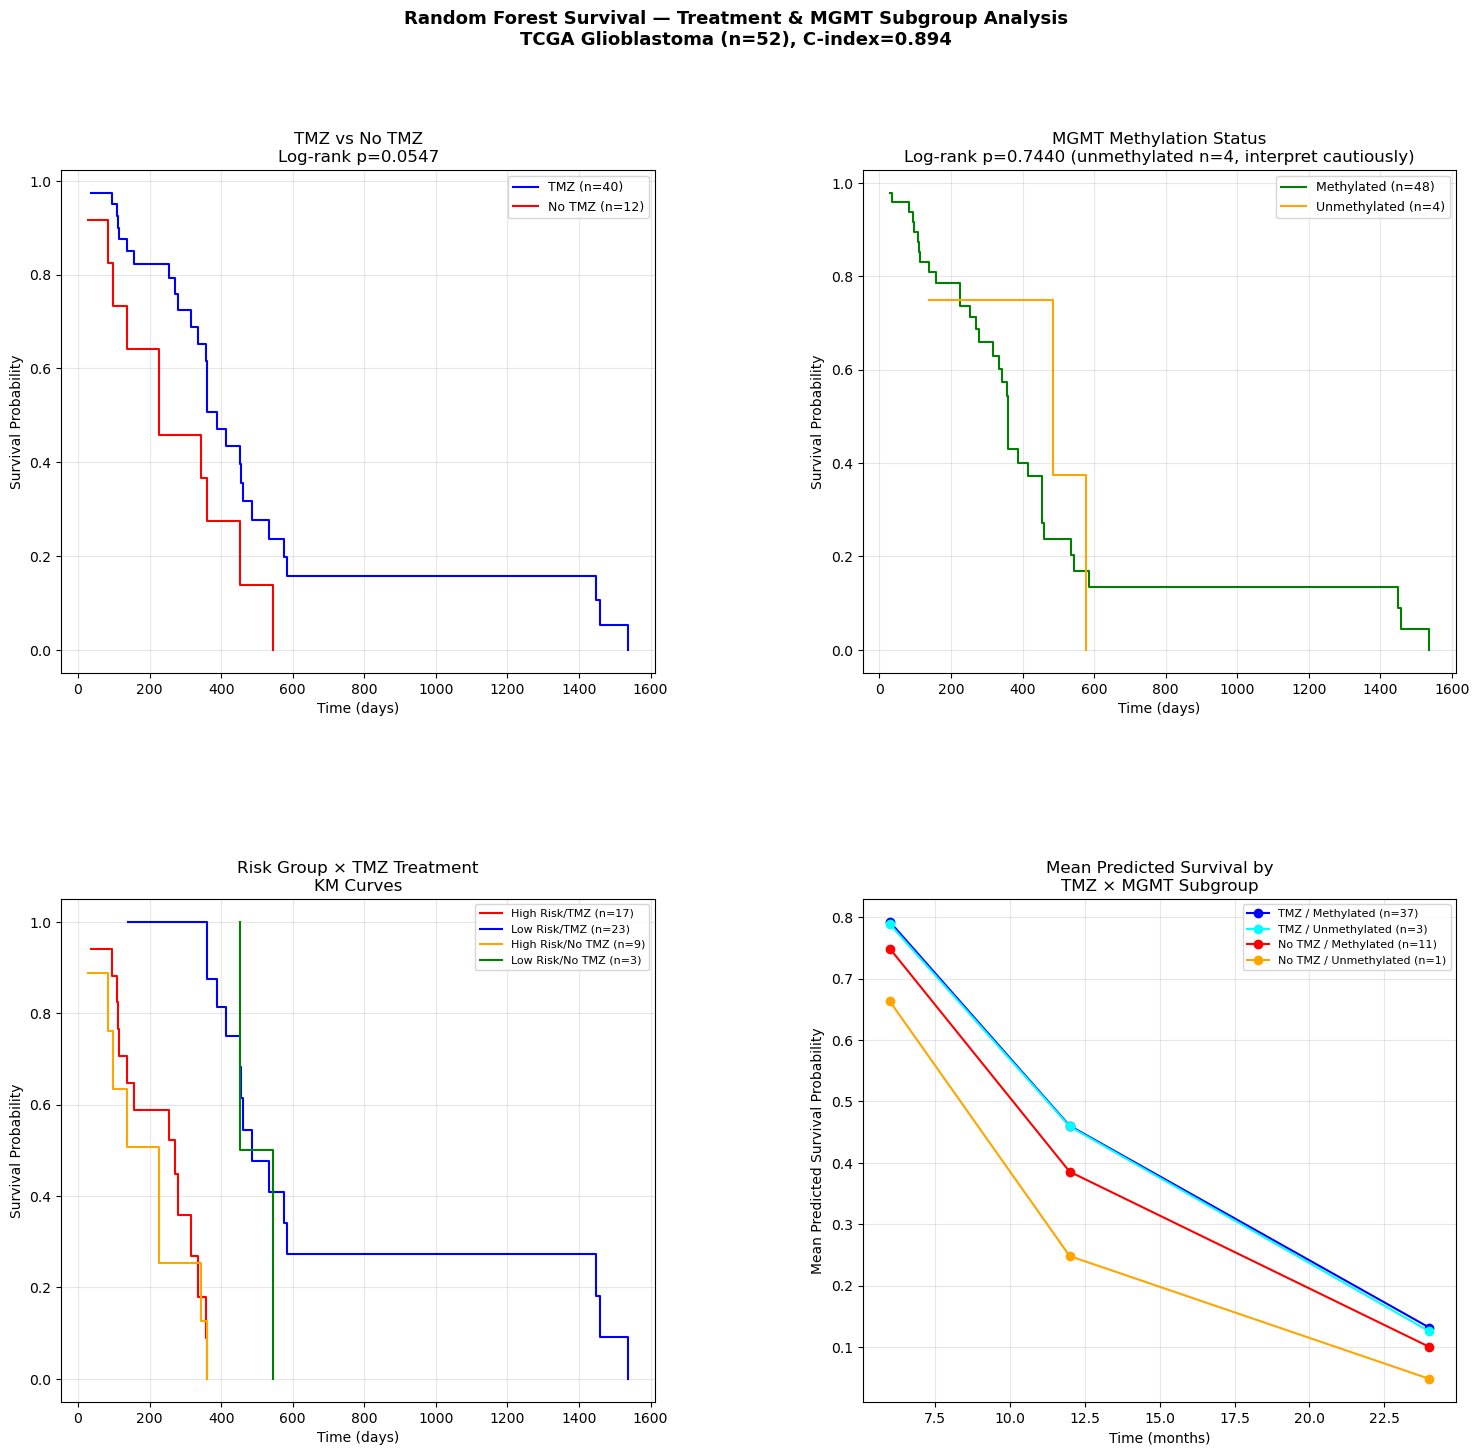

TMZ median survival:    302 days (9.9 months)
No TMZ median survival: 225 days (7.4 months)
Methylated median survival:   282 days (9.3 months)
Unmethylated median survival: 350 days (11.5 months)

Subgroup counts:
subgroup
TMZ / Methylated         37
No TMZ / Methylated      11
TMZ / Unmethylated        3
No TMZ / Unmethylated     1
Name: count, dtype: int64


In [57]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines.statistics import logrank_test

# Add TMZ and MGMT to full_df
full_df["TMZ"] = merged_df["TMZ_binary"].values
full_df["MGMT"] = merged_df["Methylation_Status"].values
full_df["TMZ_label"] = full_df["TMZ"].map({1: "TMZ", 0: "No TMZ"})
full_df["MGMT_label"] = full_df["MGMT"].map({1.0: "Methylated", 0.0: "Unmethylated"})

# Create 4 subgroups
full_df["subgroup"] = full_df["TMZ_label"] + " / " + full_df["MGMT_label"]

fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# -------------------------------------------------------
# Plot 1: TMZ vs No TMZ — KM curves
# -------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
for label, color in [("TMZ", "blue"), ("No TMZ", "red")]:
    mask = full_df["TMZ_label"] == label
    times = full_df.loc[mask, "actual_time_days"].values
    events = full_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax1.step(t, s, where="post", color=color, label=f"{label} (n={mask.sum()})")

tmz = full_df[full_df["TMZ_label"] == "TMZ"]
no_tmz = full_df[full_df["TMZ_label"] == "No TMZ"]
lr1 = logrank_test(tmz["actual_time_days"], no_tmz["actual_time_days"],
                   event_observed_A=tmz["actual_event"],
                   event_observed_B=no_tmz["actual_event"])

ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Survival Probability")
ax1.set_title(f"TMZ vs No TMZ\nLog-rank p={lr1.p_value:.4f}")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# -------------------------------------------------------
# Plot 2: MGMT Methylation Status — KM curves
# -------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
for label, color in [("Methylated", "green"), ("Unmethylated", "orange")]:
    mask = full_df["MGMT_label"] == label
    times = full_df.loc[mask, "actual_time_days"].values
    events = full_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax2.step(t, s, where="post", color=color, label=f"{label} (n={mask.sum()})")

meth = full_df[full_df["MGMT_label"] == "Methylated"]
unmeth = full_df[full_df["MGMT_label"] == "Unmethylated"]
lr2 = logrank_test(meth["actual_time_days"], unmeth["actual_time_days"],
                   event_observed_A=meth["actual_event"],
                   event_observed_B=unmeth["actual_event"])

ax2.set_xlabel("Time (days)")
ax2.set_ylabel("Survival Probability")
ax2.set_title(f"MGMT Methylation Status\nLog-rank p={lr2.p_value:.4f} (unmethylated n=4, interpret cautiously)")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# -------------------------------------------------------
# Plot 3: Risk Group within TMZ patients
# -------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

subgroup_styles = [
    ("High Risk", "TMZ",    "red"),
    ("Low Risk",  "TMZ",    "blue"),
    ("High Risk", "No TMZ", "orange"),
    ("Low Risk",  "No TMZ", "green")
]

for risk, tmz_label, color in subgroup_styles:
    mask = (full_df["risk_group"] == risk) & (full_df["TMZ_label"] == tmz_label)
    if mask.sum() < 3:
        continue
    times = full_df.loc[mask, "actual_time_days"].values
    events = full_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax3.step(t, s, where="post", color=color, label=f"{risk}/{tmz_label} (n={mask.sum()})")

ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Survival Probability")
ax3.set_title("Risk Group × TMZ Treatment\nKM Curves")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# -------------------------------------------------------
# Plot 4: Predicted survival probabilities by subgroup
# -------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])
subgroups = ["TMZ / Methylated", "TMZ / Unmethylated", 
             "No TMZ / Methylated", "No TMZ / Unmethylated"]
colors4 = ["blue", "cyan", "red", "orange"]

for sg, color in zip(subgroups, colors4):
    mask = full_df["subgroup"] == sg
    if mask.sum() == 0:
        continue
    vals_6  = full_df.loc[mask, "pred_surv_prob_6mo"].mean()
    vals_12 = full_df.loc[mask, "pred_surv_prob_12mo"].mean()
    vals_24 = full_df.loc[mask, "pred_surv_prob_24mo"].mean()
    ax4.plot([6, 12, 24], [vals_6, vals_12, vals_24], 
             marker="o", color=color, label=f"{sg} (n={mask.sum()})")

ax4.set_xlabel("Time (months)")
ax4.set_ylabel("Mean Predicted Survival Probability")
ax4.set_title("Mean Predicted Survival by\nTMZ × MGMT Subgroup")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

fig.suptitle("Random Forest Survival — Treatment & MGMT Subgroup Analysis\nTCGA Glioblastoma (n=52), C-index=0.894",
             fontsize=13, fontweight="bold")
plt.savefig("TCGA_data/rf_subgroup_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"TMZ median survival:    {np.median(tmz['actual_time_days']):.0f} days ({np.median(tmz['actual_time_days'])/30.4:.1f} months)")
print(f"No TMZ median survival: {np.median(no_tmz['actual_time_days']):.0f} days ({np.median(no_tmz['actual_time_days'])/30.4:.1f} months)")
print(f"Methylated median survival:   {np.median(meth['actual_time_days']):.0f} days ({np.median(meth['actual_time_days'])/30.4:.1f} months)")
print(f"Unmethylated median survival: {np.median(unmeth['actual_time_days']):.0f} days ({np.median(unmeth['actual_time_days'])/30.4:.1f} months)")
print(f"\nSubgroup counts:\n{full_df['subgroup'].value_counts()}")

In [58]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_censored
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=42)

# --- Cross-validate GBM ---
fold_scores = []
for train_idx, test_idx in kf.split(X_rf):
    X_train, X_test = X_rf[train_idx], X_rf[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    gbm = GradientBoostingSurvivalAnalysis(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )
    gbm.fit(X_train, y_train)
    
    pred = gbm.predict(X_test)
    c = concordance_index_censored(y_test["event"], y_test["time"], pred)[0]
    fold_scores.append(c)

print("Per-fold C-indices:", [round(s, 3) for s in fold_scores])
print("Mean C-index:", round(np.mean(fold_scores), 3))
print("Std:", round(np.std(fold_scores), 3))

# --- Fit final model on full data ---
gbm_final = GradientBoostingSurvivalAnalysis(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gbm_final.fit(X_rf, y)

# --- Feature Importance ---
importance_df = pd.DataFrame({
    "feature": selected_features_09,
    "importance": gbm_final.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.to_csv("TCGA_data/gbm_importance.csv", index=False)

print("\nTop 15 features by importance:")
print(importance_df.head(15).to_string())

print("\n========== FULL MODEL COMPARISON ==========")
print(f"{'Model':<25} {'C-index':<12} {'Std'}")
print(f"{'LASSO (l1=1.0)':<25} {'0.690':<12} {'-'}")
print(f"{'ElasticNet (l1=0.9)':<25} {'0.747':<12} {'-'}")
print(f"{'ElasticNet (l1=0.5)':<25} {'0.739':<12} {'-'}")
print(f"{'Random Forest':<25} {'0.894':<12} {'0.081'}")
print(f"{'Gradient Boosting':<25} {round(np.mean(fold_scores), 3):<12} {round(np.std(fold_scores), 3)}")

Per-fold C-indices: [0.727, 0.7, 1.0, 1.0, 0.857, 0.857, 1.0, 0.5, 0.889, 1.0]
Mean C-index: 0.853
Std: 0.159

Top 15 features by importance:
            feature  importance
9   ENSG00000034152    0.235631
1   ENSG00000054356    0.141463
31  ENSG00000145623    0.081630
70  ENSG00000167779    0.072022
21  ENSG00000163923    0.038007
16  ENSG00000184903    0.035108
5   ENSG00000200376    0.029770
4   ENSG00000116525    0.029493
48  ENSG00000137843    0.027933
18  ENSG00000009413    0.026462
30  ENSG00000279692    0.024362
19  ENSG00000186832    0.019661
3   ENSG00000237039    0.017328
40  ENSG00000091129    0.017153
69  ENSG00000223969    0.016677

========== FULL MODEL COMPARISON ==========
Model                     C-index      Std
LASSO (l1=1.0)            0.690        -
ElasticNet (l1=0.9)       0.747        -
ElasticNet (l1=0.5)       0.739        -
Random Forest             0.894        0.081
Gradient Boosting         0.853        0.159


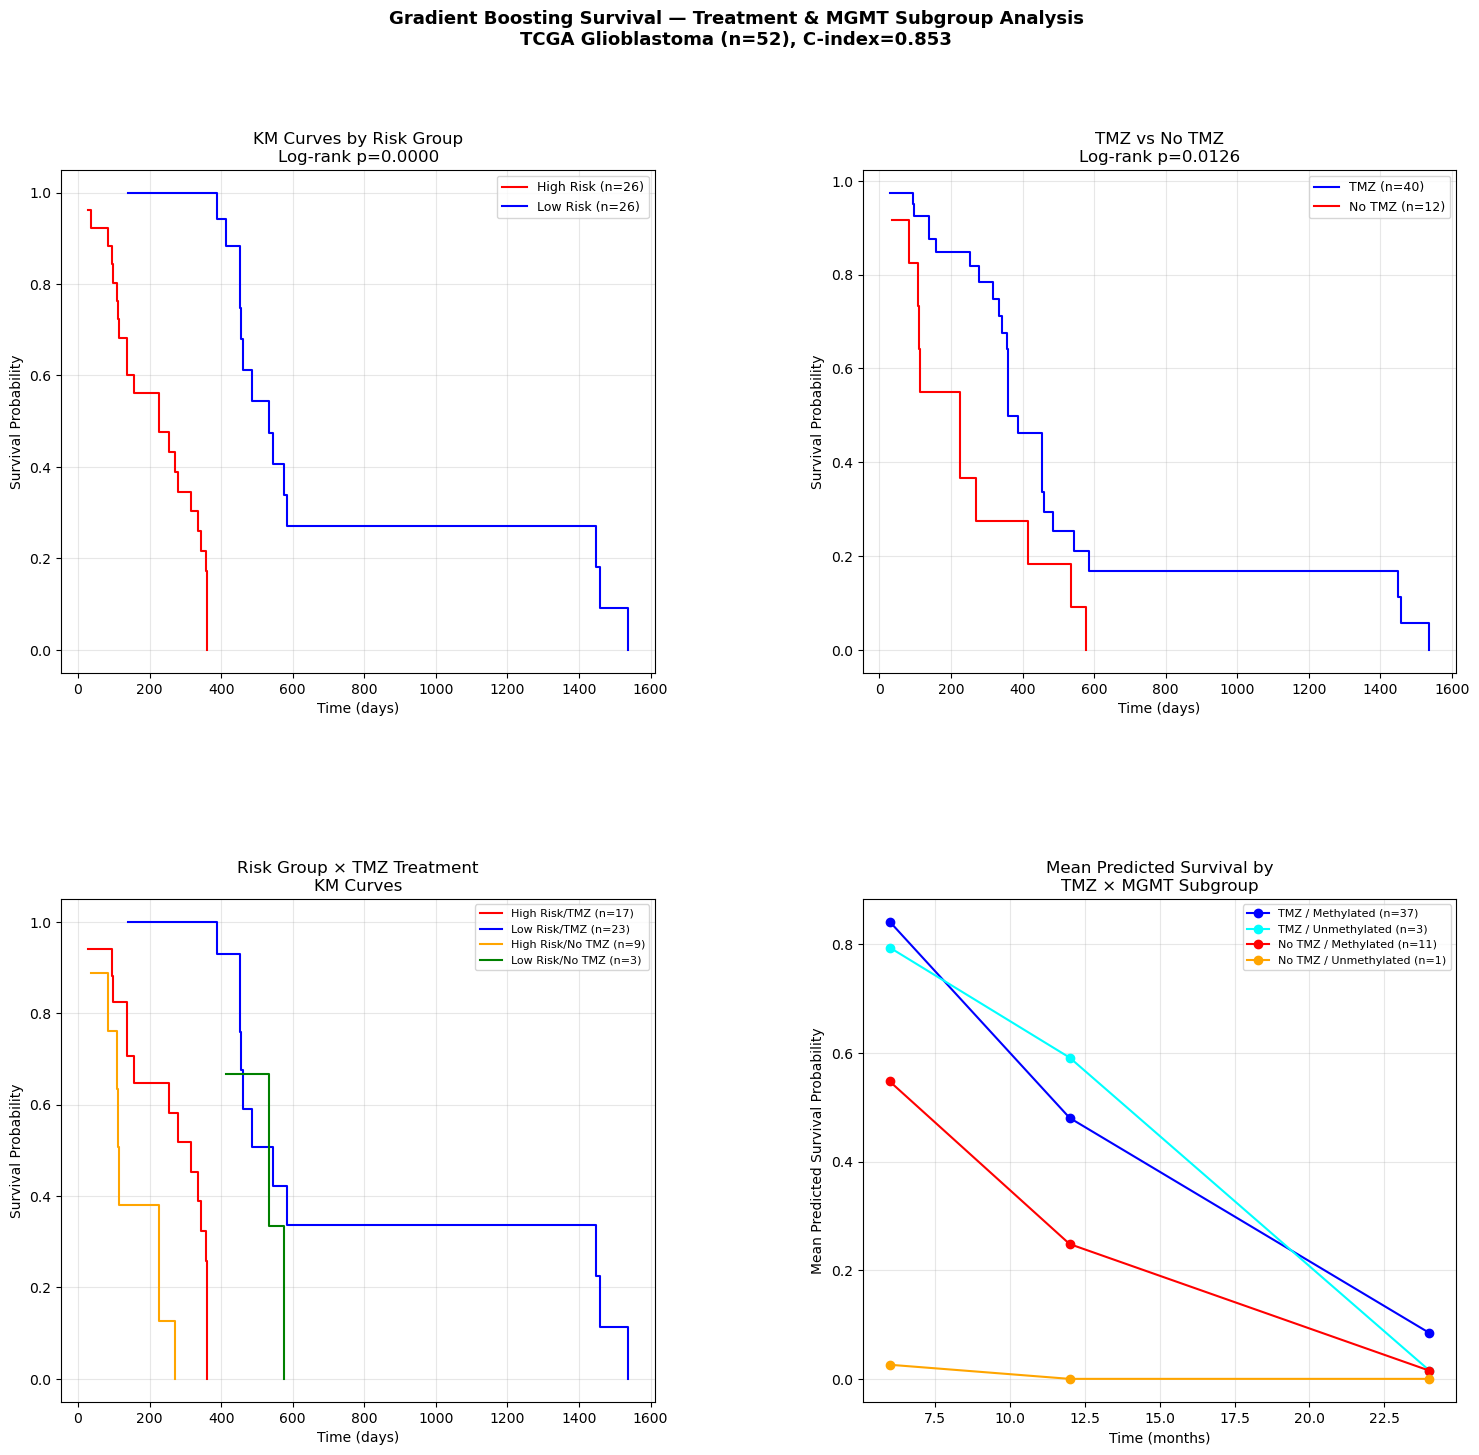

High Risk median survival: 220 days (7.2 months)
Low Risk median survival:  453 days (14.9 months)
TMZ median survival:       339 days (11.2 months)
No TMZ median survival:    170 days (5.6 months)

Subgroup counts:
subgroup
TMZ / Methylated         37
No TMZ / Methylated      11
TMZ / Unmethylated        3
No TMZ / Unmethylated     1
Name: count, dtype: int64


In [59]:
# --- GBM Risk Scores and Survival Functions ---
gbm_risk_scores = gbm_final.predict(X_rf)
gbm_surv_funcs = gbm_final.predict_survival_function(X_rf)
gbm_median_risk = np.median(gbm_risk_scores)

# --- Build full prediction dataframe ---
rows = []
for i, fn in enumerate(gbm_surv_funcs):
    actual_time = merged_df["OS.time"].values[i]
    actual_event = merged_df["event"].values[i]
    row = {
        "sample": merged_df["sample"].values[i],
        "risk_score": round(gbm_risk_scores[i], 3),
        "risk_group": "High Risk" if gbm_risk_scores[i] > gbm_median_risk else "Low Risk",
        "actual_time_days": actual_time,
        "actual_event": actual_event,
        "TMZ_label": "TMZ" if merged_df["TMZ_binary"].values[i] == 1 else "No TMZ",
        "MGMT_label": "Methylated" if merged_df["Methylation_Status"].values[i] == 1.0 else "Unmethylated",
        "pred_surv_prob_6mo":  round(np.interp(180, fn.x, fn.y), 3),
        "pred_surv_prob_12mo": round(np.interp(365, fn.x, fn.y), 3),
        "pred_surv_prob_24mo": round(np.interp(730, fn.x, fn.y), 3),
        "pred_surv_at_actual_time": round(np.interp(actual_time, fn.x, fn.y), 3)
    }
    rows.append(row)

gbm_df = pd.DataFrame(rows).sort_values("risk_score", ascending=False).reset_index(drop=True)
gbm_df["subgroup"] = gbm_df["TMZ_label"] + " / " + gbm_df["MGMT_label"]
gbm_df.to_csv("TCGA_data/gbm_full_predictions.csv", index=False)

# --- Comprehensive Figure ---
fig = plt.figure(figsize=(18, 16))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Plot 1: KM by Risk Group ---
ax1 = fig.add_subplot(gs[0, 0])
for group, color in [("High Risk", "red"), ("Low Risk", "blue")]:
    mask = gbm_df["risk_group"] == group
    times = gbm_df.loc[mask, "actual_time_days"].values
    events = gbm_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax1.step(t, s, where="post", color=color, label=f"{group} (n={mask.sum()})")

high = gbm_df[gbm_df["risk_group"] == "High Risk"]
low  = gbm_df[gbm_df["risk_group"] == "Low Risk"]
lr1 = logrank_test(high["actual_time_days"], low["actual_time_days"],
                   event_observed_A=high["actual_event"],
                   event_observed_B=low["actual_event"])

ax1.set_xlabel("Time (days)")
ax1.set_ylabel("Survival Probability")
ax1.set_title(f"KM Curves by Risk Group\nLog-rank p={lr1.p_value:.4f}")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# --- Plot 2: TMZ vs No TMZ ---
ax2 = fig.add_subplot(gs[0, 1])
for label, color in [("TMZ", "blue"), ("No TMZ", "red")]:
    mask = gbm_df["TMZ_label"] == label
    times = gbm_df.loc[mask, "actual_time_days"].values
    events = gbm_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax2.step(t, s, where="post", color=color, label=f"{label} (n={mask.sum()})")

tmz = gbm_df[gbm_df["TMZ_label"] == "TMZ"]
no_tmz = gbm_df[gbm_df["TMZ_label"] == "No TMZ"]
lr2 = logrank_test(tmz["actual_time_days"], no_tmz["actual_time_days"],
                   event_observed_A=tmz["actual_event"],
                   event_observed_B=no_tmz["actual_event"])

ax2.set_xlabel("Time (days)")
ax2.set_ylabel("Survival Probability")
ax2.set_title(f"TMZ vs No TMZ\nLog-rank p={lr2.p_value:.4f}")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# --- Plot 3: Risk Group x TMZ ---
ax3 = fig.add_subplot(gs[1, 0])
subgroup_styles = [
    ("High Risk", "TMZ",    "red"),
    ("Low Risk",  "TMZ",    "blue"),
    ("High Risk", "No TMZ", "orange"),
    ("Low Risk",  "No TMZ", "green")
]
for risk, tmz_label, color in subgroup_styles:
    mask = (gbm_df["risk_group"] == risk) & (gbm_df["TMZ_label"] == tmz_label)
    if mask.sum() < 3:
        continue
    times = gbm_df.loc[mask, "actual_time_days"].values
    events = gbm_df.loc[mask, "actual_event"].values.astype(bool)
    t, s = kaplan_meier_estimator(events, times)
    ax3.step(t, s, where="post", color=color, label=f"{risk}/{tmz_label} (n={mask.sum()})")

ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Survival Probability")
ax3.set_title("Risk Group × TMZ Treatment\nKM Curves")
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# --- Plot 4: Mean Predicted Survival by TMZ x MGMT Subgroup ---
ax4 = fig.add_subplot(gs[1, 1])
subgroups = ["TMZ / Methylated", "TMZ / Unmethylated",
             "No TMZ / Methylated", "No TMZ / Unmethylated"]
colors4 = ["blue", "cyan", "red", "orange"]

for sg, color in zip(subgroups, colors4):
    mask = gbm_df["subgroup"] == sg
    if mask.sum() == 0:
        continue
    vals = [gbm_df.loc[mask, "pred_surv_prob_6mo"].mean(),
            gbm_df.loc[mask, "pred_surv_prob_12mo"].mean(),
            gbm_df.loc[mask, "pred_surv_prob_24mo"].mean()]
    ax4.plot([6, 12, 24], vals, marker="o", color=color, label=f"{sg} (n={mask.sum()})")

ax4.set_xlabel("Time (months)")
ax4.set_ylabel("Mean Predicted Survival Probability")
ax4.set_title("Mean Predicted Survival by\nTMZ × MGMT Subgroup")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

fig.suptitle("Gradient Boosting Survival — Treatment & MGMT Subgroup Analysis\nTCGA Glioblastoma (n=52), C-index=0.853",
             fontsize=13, fontweight="bold")
plt.savefig("TCGA_data/gbm_subgroup_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"High Risk median survival: {np.median(high['actual_time_days']):.0f} days ({np.median(high['actual_time_days'])/30.4:.1f} months)")
print(f"Low Risk median survival:  {np.median(low['actual_time_days']):.0f} days ({np.median(low['actual_time_days'])/30.4:.1f} months)")
print(f"TMZ median survival:       {np.median(tmz['actual_time_days']):.0f} days ({np.median(tmz['actual_time_days'])/30.4:.1f} months)")
print(f"No TMZ median survival:    {np.median(no_tmz['actual_time_days']):.0f} days ({np.median(no_tmz['actual_time_days'])/30.4:.1f} months)")
print(f"\nSubgroup counts:\n{gbm_df['subgroup'].value_counts()}")

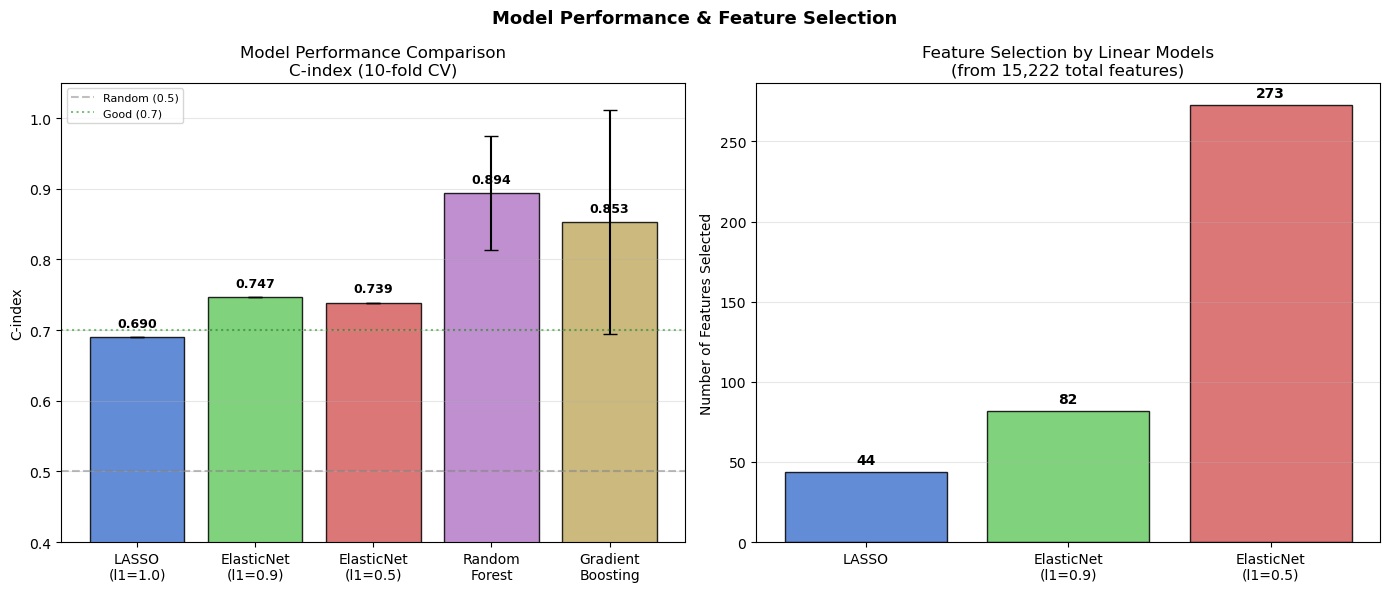

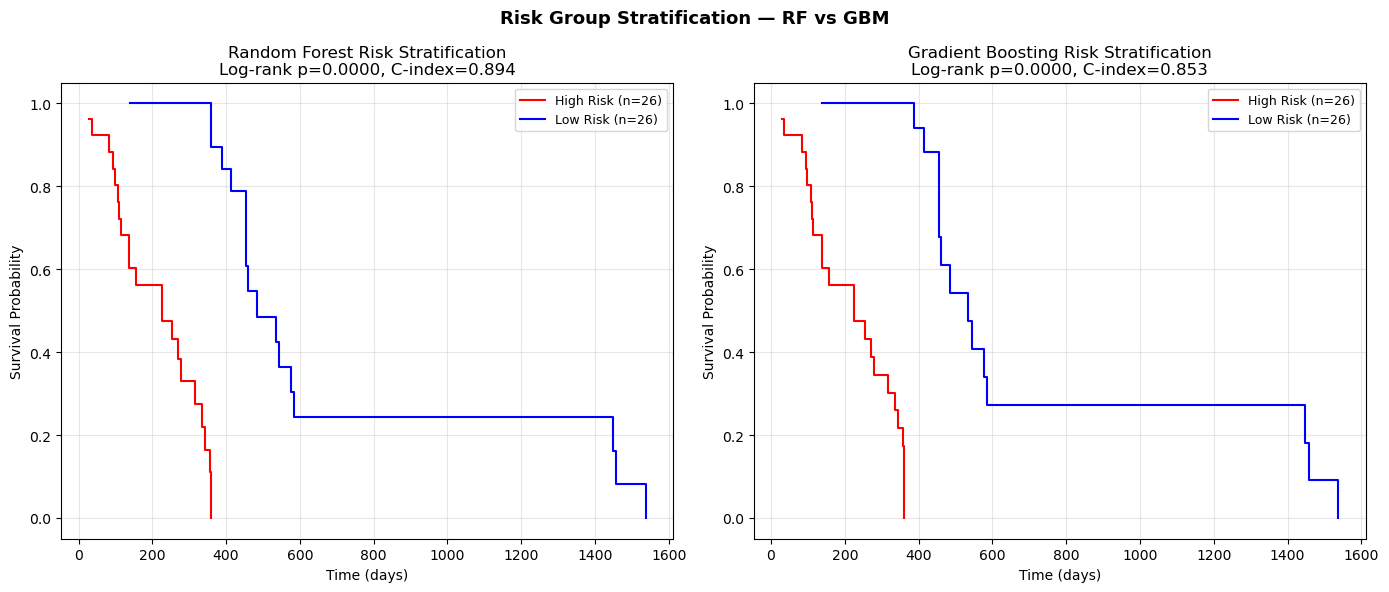

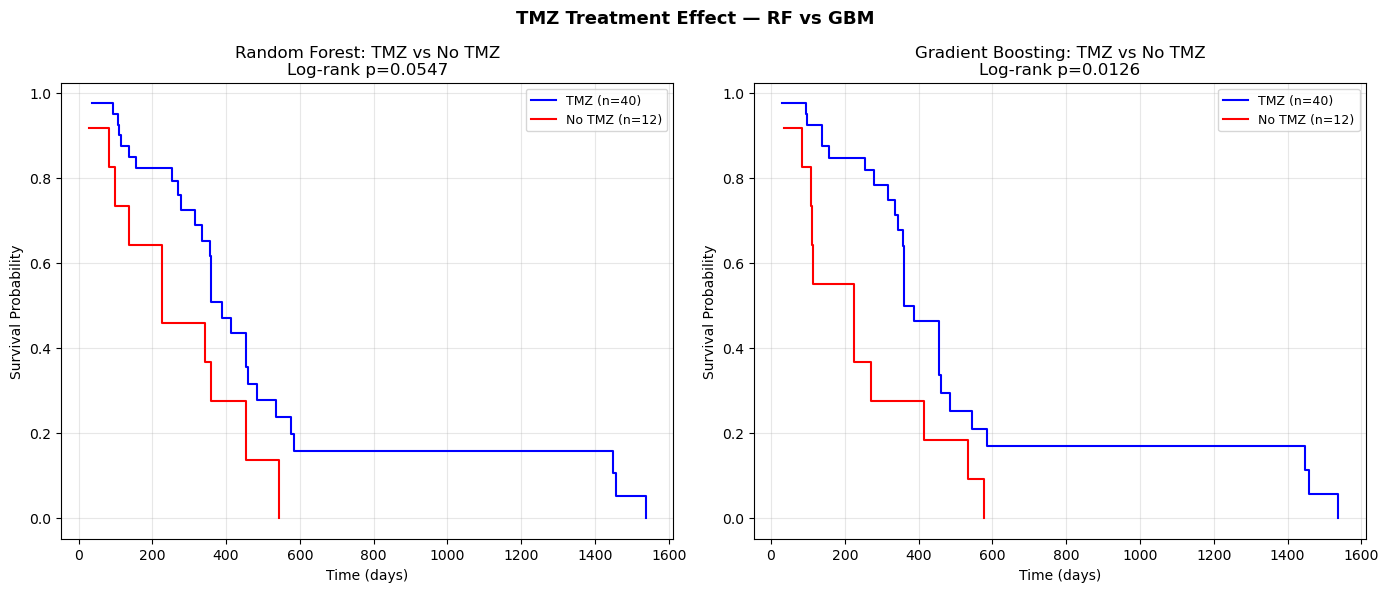

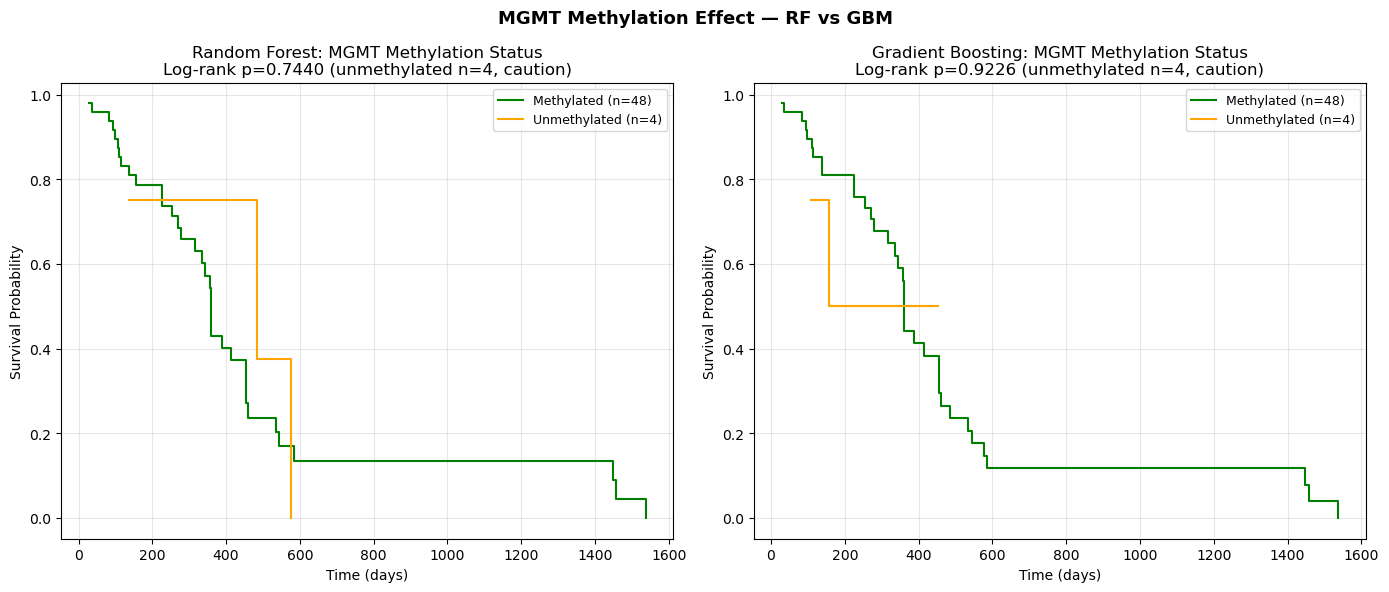

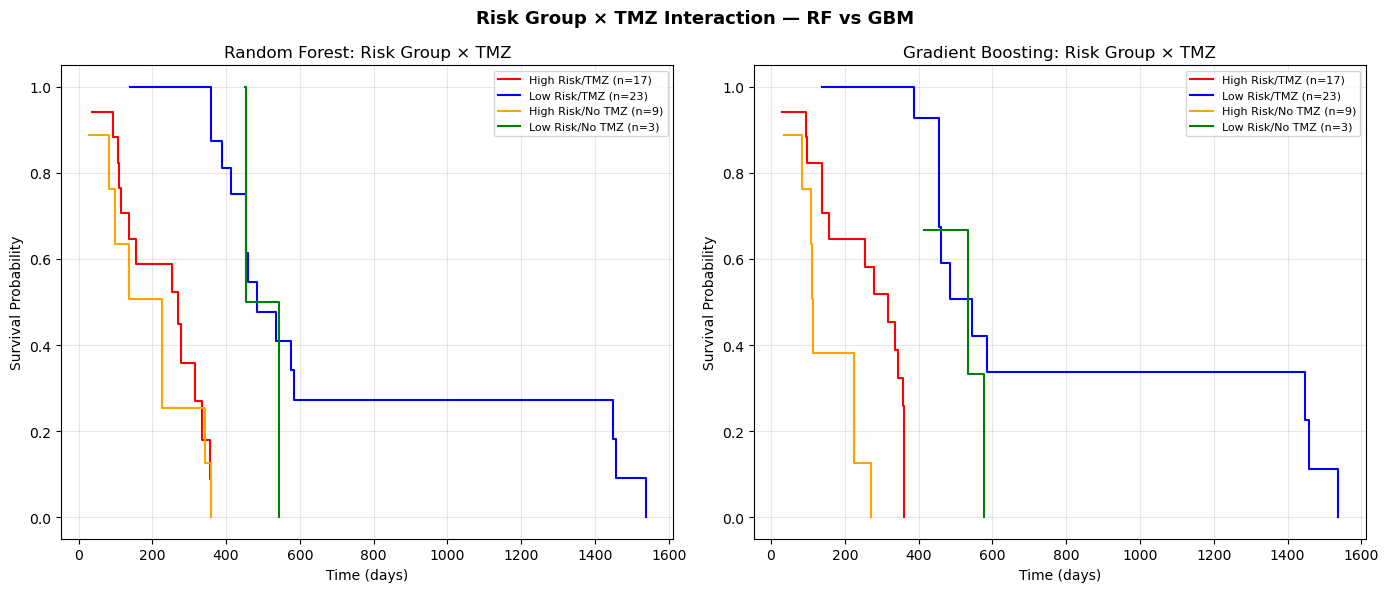

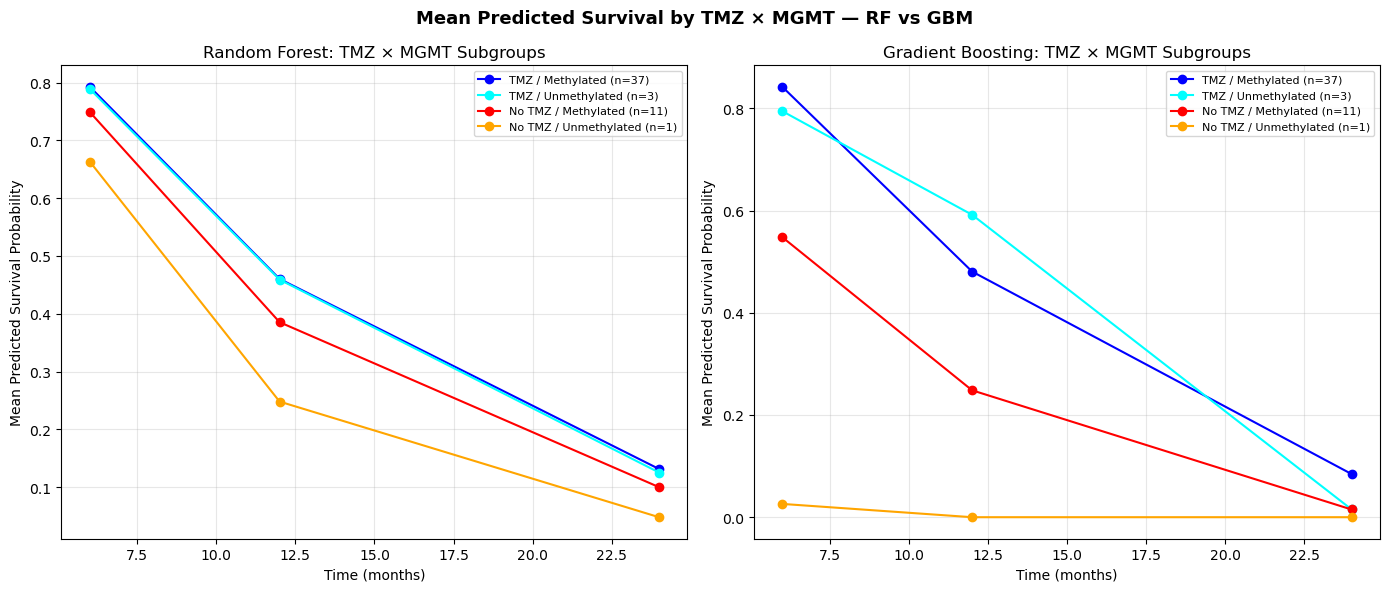

All figures saved:
  TCGA_data/fig1_model_performance.png
  TCGA_data/fig2_risk_groups.png
  TCGA_data/fig3_tmz_comparison.png
  TCGA_data/fig4_mgmt_comparison.png
  TCGA_data/fig5_risk_x_tmz.png
  TCGA_data/fig6_tmz_x_mgmt.png


In [61]:
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator
from lifelines.statistics import logrank_test
import numpy as np

# -------------------------------------------------------
# Figure 1: Model Performance
# -------------------------------------------------------
fig1, axes = plt.subplots(1, 2, figsize=(14, 6))

# C-index bar chart
models = ["LASSO\n(l1=1.0)", "ElasticNet\n(l1=0.9)", "ElasticNet\n(l1=0.5)",
          "Random\nForest", "Gradient\nBoosting"]
c_indices = [0.690, 0.747, 0.739, 0.894, 0.853]
stds = [0, 0, 0, 0.081, 0.159]
colors_bar = ["#4878CF", "#6ACC65", "#D65F5F", "#B47CC7", "#C4AD66"]

bars = axes[0].bar(models, c_indices, color=colors_bar, alpha=0.85, edgecolor="black")
axes[0].errorbar(range(len(models)), c_indices, yerr=stds, fmt="none",
                 color="black", capsize=5, linewidth=1.5)
axes[0].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Random (0.5)")
axes[0].axhline(y=0.7, color="green", linestyle=":", alpha=0.5, label="Good (0.7)")
for bar, val in zip(bars, c_indices):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_ylabel("C-index")
axes[0].set_title("Model Performance Comparison\nC-index (10-fold CV)")
axes[0].set_ylim(0.4, 1.05)
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Features selected
model_names = ["LASSO", "ElasticNet\n(l1=0.9)", "ElasticNet\n(l1=0.5)"]
n_features = [44, 82, 273]
bars2 = axes[1].bar(model_names, n_features, color=["#4878CF", "#6ACC65", "#D65F5F"],
                    alpha=0.85, edgecolor="black")
for bar, val in zip(bars2, n_features):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 3, str(val),
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_ylabel("Number of Features Selected")
axes[1].set_title("Feature Selection by Linear Models\n(from 15,222 total features)")
axes[1].grid(axis="y", alpha=0.3)

fig1.suptitle("Model Performance & Feature Selection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("TCGA_data/fig1_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Figure 2: Risk Group KM — RF vs GBM
# -------------------------------------------------------
fig2, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, title, c_idx in [
    (axes[0], full_df, "Random Forest", "0.894"),
    (axes[1], gbm_df,  "Gradient Boosting", "0.853")
]:
    for group, color in [("High Risk", "red"), ("Low Risk", "blue")]:
        mask = df["risk_group"] == group
        t, s = kaplan_meier_estimator(
            df.loc[mask, "actual_event"].values.astype(bool),
            df.loc[mask, "actual_time_days"].values)
        ax.step(t, s, where="post", color=color, label=f"{group} (n={mask.sum()})")
    
    high = df[df["risk_group"] == "High Risk"]
    low  = df[df["risk_group"] == "Low Risk"]
    lr = logrank_test(high["actual_time_days"], low["actual_time_days"],
                      event_observed_A=high["actual_event"],
                      event_observed_B=low["actual_event"])
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival Probability")
    ax.set_title(f"{title} Risk Stratification\nLog-rank p={lr.p_value:.4f}, C-index={c_idx}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig2.suptitle("Risk Group Stratification — RF vs GBM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("TCGA_data/fig2_risk_groups.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Figure 3: TMZ Treatment Comparison — RF vs GBM
# -------------------------------------------------------
fig3, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, title in [
    (axes[0], full_df, "Random Forest"),
    (axes[1], gbm_df,  "Gradient Boosting")
]:
    for label, color in [("TMZ", "blue"), ("No TMZ", "red")]:
        mask = df["TMZ_label"] == label
        t, s = kaplan_meier_estimator(
            df.loc[mask, "actual_event"].values.astype(bool),
            df.loc[mask, "actual_time_days"].values)
        ax.step(t, s, where="post", color=color, label=f"{label} (n={mask.sum()})")
    
    tmz    = df[df["TMZ_label"] == "TMZ"]
    no_tmz = df[df["TMZ_label"] == "No TMZ"]
    lr = logrank_test(tmz["actual_time_days"], no_tmz["actual_time_days"],
                      event_observed_A=tmz["actual_event"],
                      event_observed_B=no_tmz["actual_event"])
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival Probability")
    ax.set_title(f"{title}: TMZ vs No TMZ\nLog-rank p={lr.p_value:.4f}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig3.suptitle("TMZ Treatment Effect — RF vs GBM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("TCGA_data/fig3_tmz_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Figure 4: MGMT Methylation Comparison — RF vs GBM
# -------------------------------------------------------
fig4, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df, title in [
    (axes[0], full_df, "Random Forest"),
    (axes[1], gbm_df,  "Gradient Boosting")
]:
    for label, color in [("Methylated", "green"), ("Unmethylated", "orange")]:
        mask = df["MGMT_label"] == label
        if mask.sum() < 2:
            continue
        t, s = kaplan_meier_estimator(
            df.loc[mask, "actual_event"].values.astype(bool),
            df.loc[mask, "actual_time_days"].values)
        ax.step(t, s, where="post", color=color, label=f"{label} (n={mask.sum()})")

    meth   = df[df["MGMT_label"] == "Methylated"]
    unmeth = df[df["MGMT_label"] == "Unmethylated"]
    if unmeth.shape[0] >= 2:
        lr = logrank_test(meth["actual_time_days"], unmeth["actual_time_days"],
                          event_observed_A=meth["actual_event"],
                          event_observed_B=unmeth["actual_event"])
        pval = f"{lr.p_value:.4f}"
    else:
        pval = "N/A (n too small)"
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival Probability")
    ax.set_title(f"{title}: MGMT Methylation Status\nLog-rank p={pval} (unmethylated n=4, caution)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig4.suptitle("MGMT Methylation Effect — RF vs GBM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("TCGA_data/fig4_mgmt_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Figure 5: Risk Group x TMZ — RF vs GBM
# -------------------------------------------------------
fig5, axes = plt.subplots(1, 2, figsize=(14, 6))

subgroup_styles = [
    ("High Risk", "TMZ",    "red",    "High Risk/TMZ"),
    ("Low Risk",  "TMZ",    "blue",   "Low Risk/TMZ"),
    ("High Risk", "No TMZ", "orange", "High Risk/No TMZ"),
    ("Low Risk",  "No TMZ", "green",  "Low Risk/No TMZ")
]

for ax, df, title in [
    (axes[0], full_df, "Random Forest"),
    (axes[1], gbm_df,  "Gradient Boosting")
]:
    for risk, tmz_label, color, label in subgroup_styles:
        mask = (df["risk_group"] == risk) & (df["TMZ_label"] == tmz_label)
        if mask.sum() < 3:
            continue
        t, s = kaplan_meier_estimator(
            df.loc[mask, "actual_event"].values.astype(bool),
            df.loc[mask, "actual_time_days"].values)
        ax.step(t, s, where="post", color=color, label=f"{label} (n={mask.sum()})")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("Survival Probability")
    ax.set_title(f"{title}: Risk Group × TMZ")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig5.suptitle("Risk Group × TMZ Interaction — RF vs GBM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("TCGA_data/fig5_risk_x_tmz.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Figure 6: Mean Predicted Survival — TMZ x MGMT Subgroups
# -------------------------------------------------------
fig6, axes = plt.subplots(1, 2, figsize=(14, 6))

subgroups  = ["TMZ / Methylated", "TMZ / Unmethylated",
              "No TMZ / Methylated", "No TMZ / Unmethylated"]
colors6    = ["blue", "cyan", "red", "orange"]
time_pts   = [6, 12, 24]

for ax, df, title in [
    (axes[0], full_df, "Random Forest"),
    (axes[1], gbm_df,  "Gradient Boosting")
]:
    for sg, color in zip(subgroups, colors6):
        mask = df["subgroup"] == sg
        if mask.sum() == 0:
            continue
        vals = [df.loc[mask, "pred_surv_prob_6mo"].mean(),
                df.loc[mask, "pred_surv_prob_12mo"].mean(),
                df.loc[mask, "pred_surv_prob_24mo"].mean()]
        ax.plot(time_pts, vals, marker="o", color=color,
                label=f"{sg} (n={mask.sum()})")
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Mean Predicted Survival Probability")
    ax.set_title(f"{title}: TMZ × MGMT Subgroups")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig6.suptitle("Mean Predicted Survival by TMZ × MGMT — RF vs GBM", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("TCGA_data/fig6_tmz_x_mgmt.png", dpi=150, bbox_inches="tight")
plt.show()

print("All figures saved:")
print("  TCGA_data/fig1_model_performance.png")
print("  TCGA_data/fig2_risk_groups.png")
print("  TCGA_data/fig3_tmz_comparison.png")
print("  TCGA_data/fig4_mgmt_comparison.png")
print("  TCGA_data/fig5_risk_x_tmz.png")
print("  TCGA_data/fig6_tmz_x_mgmt.png")